In [7]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (accuracy_score, f1_score, balanced_accuracy_score,
                             log_loss, confusion_matrix, classification_report)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 50)

## Завантаження даних

In [8]:
path = kagglehub.dataset_download("muratkokludataset/dry-bean-dataset")

dataset_file = None
for root, dirs, files in os.walk(path):
    for file in files:
        if file.endswith('.xlsx') or file.endswith('.csv'):
            dataset_file = os.path.join(root, file)
            break 
    if dataset_file:
        break

if dataset_file is None:
    raise FileNotFoundError("У завантаженому датасеті не знайдено файлів .xlsx або .csv")

print(f"Дані успішно знайдено: {dataset_file}")

if dataset_file.endswith('.xlsx'):
    df = pd.read_excel(dataset_file)
else:
    df = pd.read_csv(dataset_file)

TARGET = "Class"
print("Розмір датасету:", df.shape)
display(df.head(10))

Дані успішно знайдено: C:\Users\alina\.cache\kagglehub\datasets\muratkokludataset\dry-bean-dataset\versions\1\Dry_Bean_Dataset\Dry_Bean_Dataset.xlsx
Розмір датасету: (13611, 17)


,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272750,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER
5,30279,634.927,212.560556,181.510182,1.171067,0.520401,30600,196.347702,0.775688,0.989510,0.943852,0.923726,0.007020,0.003153,0.853270,0.999236,SEKER
6,30477,670.033,211.050155,184.039050,1.146768,0.489478,30970,196.988633,0.762402,0.984081,0.853080,0.933374,0.006925,0.003242,0.871186,0.999049,SEKER
7,30519,629.727,212.996755,182.737204,1.165591,0.513760,30847,197.124320,0.770682,0.989367,0.967109,0.925480,0.006979,0.003158,0.856514,0.998345,SEKER
8,30685,635.681,213.534145,183.157146,1.165852,0.514081,31044,197.659696,0.771561,0.988436,0.954240,0.925658,0.006959,0.003152,0.856844,0.998953,SEKER
9,30834,631.934,217.227813,180.897469,1.200834,0.553642,31120,198.139012,0.783683,0.990810,0.970278,0.912125,0.007045,0.003008,0.831973,0.999061,SEKER


## Етап 1. Дослідження даних (EDA)

Спочатку дивимось на дані "як є": типи ознак, пропуски, баланс класів.
Це нешкідливий етап — він не навчає жодних параметрів, тому його можна робити
на всьому датасеті. А от **відбір ознак і масштабування** ми зробимо вже
**після** розбиття і **тільки** на тренувальній частині.

In [ ]:
print("--- Типи ознак ---")
print(df.dtypes)
print("\n--- Пропущені значення ---")
print(df.isna().sum().sum(), "пропущених значень усього")
print("\n--- Дублікати ---")
n_dup = int(df.duplicated().sum())
print(f"{n_dup} повних дублікатів ({n_dup / len(df) * 100:.2f}%)")
if n_dup:
    df = df.drop_duplicates().reset_index(drop=True)
    print("Розмір після видалення дублікатів:", df.shape)

print("\n--- Розподіл цільової змінної ---")
print(df[TARGET].value_counts())
print("\nЧастки класів, %:")
print((df[TARGET].value_counts(normalize=True) * 100).round(2))


--- Типи ознак ---
Area                 int64
Perimeter          float64
MajorAxisLength    float64
MinorAxisLength    float64
AspectRation       float64
Eccentricity       float64
ConvexArea           int64
EquivDiameter      float64
Extent             float64
Solidity           float64
roundness          float64
Compactness        float64
ShapeFactor1       float64
ShapeFactor2       float64
ShapeFactor3       float64
ShapeFactor4       float64
Class               object
dtype: object

--- Пропущені значення ---
0 пропущених значень усього

--- Дублікати ---
68 повних дублікатів (0.50%)
Розмір після видалення дублікатів: (13543, 17)

--- Розподіл цільової змінної ---
Class
DERMASON    3546
SIRA        2636
SEKER       2027
HOROZ       1860
CALI        1630
BARBUNYA    1322
BOMBAY       522
Name: count, dtype: int64

Частки класів, %:
Class
DERMASON    26.18
SIRA        19.46
SEKER       14.97
HOROZ       13.73
CALI        12.04
BARBUNYA     9.76
BOMBAY       3.85
Name: proportion, dt

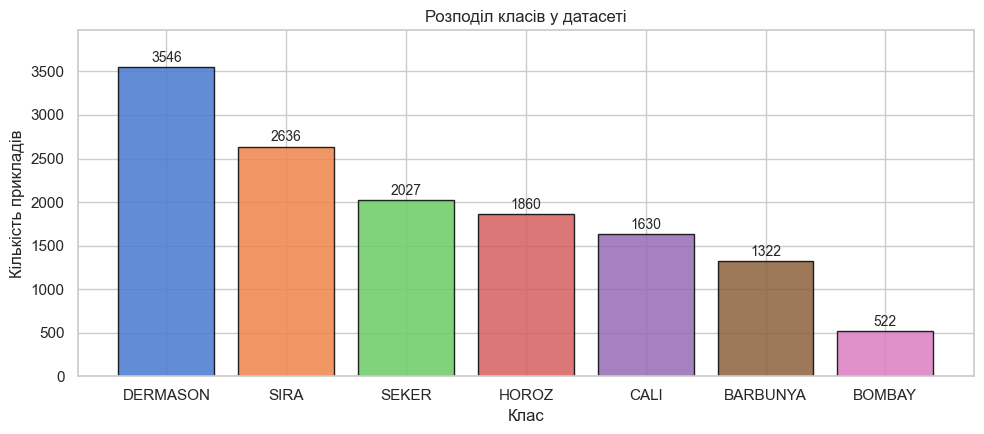

In [10]:
class_counts = df[TARGET].value_counts()
colors = sns.color_palette("muted", len(class_counts))

fig, ax = plt.subplots(figsize=(10, 4.5))
bars = ax.bar(class_counts.index, class_counts.values, color=colors, edgecolor="black", alpha=0.85)
for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, h + 25, f"{int(h)}",
            ha="center", va="bottom", fontsize=10)

ax.set_title("Розподіл класів у датасеті")
ax.set_xlabel("Клас")
ax.set_ylabel("Кількість прикладів")
ax.set_ylim(0, max(class_counts.values) * 1.12)
plt.tight_layout()
plt.show()


**Висновок до графіка.** Тут видно, скільки прикладів якого сорту є в
датасеті. Класи не однакові за розміром — найбільшого сорту в кілька разів
більше, ніж найменшого. Через це просто дивитись на accuracy небезпечно:
модель може вгадувати переважно великі класи і мати "красиву" точність, а
маленькі класи при цьому розпізнавати погано. Тому далі поряд з accuracy
завжди дивимось на macro-F1 і balanced accuracy — там усі класи важать
однаково.

In [12]:
num_cols = [c for c in df.columns if c != TARGET]
df[num_cols].describe().T[["mean", "std", "min", "50%", "max"]]

,mean,std,min,50%,max
Area,53048.460385,29392.438324,20420.000000,44580.000000,254616.000000
Perimeter,854.993406,214.722684,524.736000,793.896000,1985.370000
MajorAxisLength,319.895602,85.809260,183.601165,296.404589,738.860153
MinorAxisLength,202.365321,45.051632,122.512653,192.491117,460.198497
AspectRation,1.581075,0.245245,1.024868,1.549860,2.430306
Eccentricity,0.750315,0.091858,0.218951,0.763997,0.911423
ConvexArea,53767.986709,29844.248525,20684.000000,45122.000000,263261.000000
EquivDiameter,253.034094,59.307709,161.243764,238.245711,569.374358
Extent,0.749829,0.048939,0.555315,0.759903,0.866195
Solidity,0.987152,0.004650,0.919246,0.988288,0.994677


**Висновок до таблиці.** Видно, що ознаки мають зовсім різний масштаб:
площа зерна — це десятки тисяч, а якийсь форм-фактор — число менше за 1.
Якщо подати такі ознаки в модель "як є", градієнтний спуск буде поводитись
дивно: по великих ознаках градієнт величезний, по малих — крихітний, і
підібрати один learning rate, який підходить для всіх, майже неможливо.
Тому обов'язково стандартизуємо ознаки перед навчанням.

## Розбиття вибірки

1. **спочатку** ділимо дані на Global Test / Global Validation / FL Train Pool;
2. **потім** усе, що "навчається на даних" (кореляційний відбір ознак, середні
   та дисперсії для масштабування), рахуємо **лише на FL Train Pool**.

**Питання: чому розбиття треба робити до масштабування/кодування? Що таке Data Leakage?**

**Data Leakage (витік даних)** — це коли в модель під час навчання
"просочується" інформація, якої насправді не мало б бути. Найпростіший
приклад: якщо порахувати середнє й дисперсію (для масштабування) по всьому
датасету відразу, включно з тестовою частиною, то модель фактично вже
"підглянула" тест ще до того, як її почали оцінювати. Результат на тесті
тоді буде виглядати кращим, ніж є насправді — а на нових, справді незнайомих
даних модель покаже гірший результат, і ми будемо здивовані, чому. Те саме
стосується відбору ознак чи будь-якого кодування — усе, що "вчиться" на
даних, має вчитись тільки на train.

In [ ]:
X_all = df[num_cols].copy()
y_all_raw = df[TARGET].values

# Test — 15%
X_temp, X_test, y_temp_raw, y_test_raw = train_test_split(
    X_all, y_all_raw, test_size=0.15, stratify=y_all_raw, random_state=RANDOM_STATE)

# Validation — 12%
val_share = 0.12 / 0.85
X_pool, X_val, y_pool_raw, y_val_raw = train_test_split(
    X_temp, y_temp_raw, test_size=val_share, stratify=y_temp_raw, random_state=RANDOM_STATE)

le = LabelEncoder().fit(y_all_raw)
y_pool = le.transform(y_pool_raw)
y_val  = le.transform(y_val_raw)
y_test = le.transform(y_test_raw)
CLASS_NAMES = list(le.classes_)
C = len(CLASS_NAMES)

print("FL Train Pool   :", X_pool.shape, f"({len(X_pool)/len(df)*100:.1f}%)")
print("Global Validation:", X_val.shape, f"({len(X_val)/len(df)*100:.1f}%)")
print("Global Test     :", X_test.shape, f"({len(X_test)/len(df)*100:.1f}%)")
print("Класи:", CLASS_NAMES)

split_summary = pd.DataFrame({
    "Class": CLASS_NAMES,
    "Train Pool": pd.Series(y_pool).value_counts().sort_index().values,
    "Validation": pd.Series(y_val).value_counts().sort_index().values,
    "Test": pd.Series(y_test).value_counts().sort_index().values,
})
split_summary["Train %"] = (split_summary["Train Pool"] / len(y_pool) * 100).round(2)
split_summary["Val %"]   = (split_summary["Validation"] / len(y_val) * 100).round(2)
split_summary["Test %"]  = (split_summary["Test"] / len(y_test) * 100).round(2)
print("\n--- Зведена таблиця стратифікації ---")
display(split_summary)


FL Train Pool   : (9885, 16) (73.0%)
Global Validation: (1626, 16) (12.0%)
Global Test     : (2032, 16) (15.0%)
Класи: ['BARBUNYA', 'BOMBAY', 'CALI', 'DERMASON', 'HOROZ', 'SEKER', 'SIRA']

--- Зведена таблиця стратифікації ---


,Class,Train Pool,Validation,Test,Train %,Val %,Test %
0,BARBUNYA,965,159,198,9.76,9.78,9.74
1,BOMBAY,381,63,78,3.85,3.87,3.84
2,CALI,1189,196,245,12.03,12.05,12.06
3,DERMASON,2588,426,532,26.18,26.20,26.18
4,HOROZ,1358,223,279,13.74,13.71,13.73
5,SEKER,1480,243,304,14.97,14.94,14.96
6,SIRA,1924,316,396,19.46,19.43,19.49


### Схема розбиття даних

Нижче — наочна схема: як весь датасет ділиться на три частини і як FL Train Pool
далі розходиться по клієнтах. Global Test і Global Validation лишаються тільки
на сервері; клієнти бачать лише свою частку Train Pool.


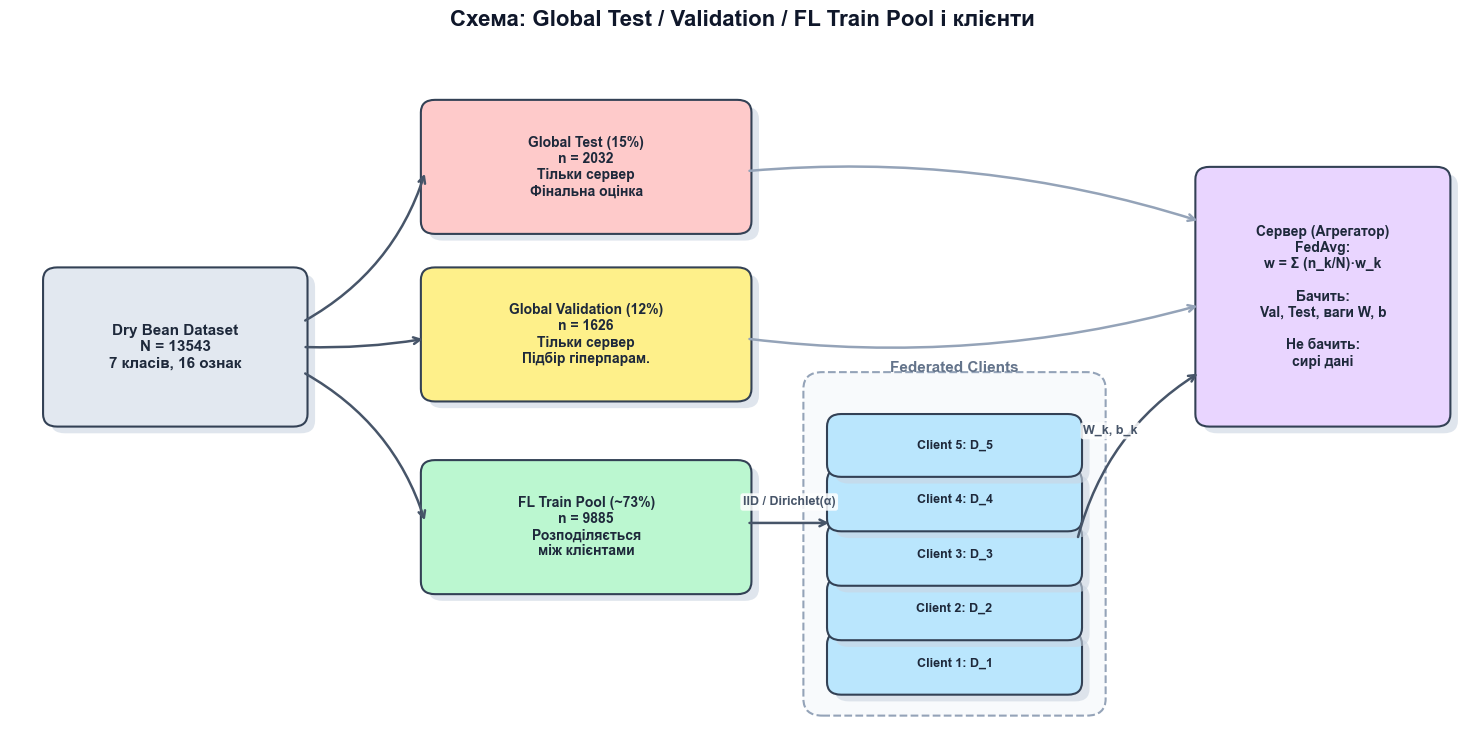

In [14]:
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(15, 7.5))
ax.axis("off")
ax.set_xlim(0, 15.5)
ax.set_ylim(-0.5, 7.5)

def box(x, y, w, h, text, color, fs=10, text_color="#1E293B"):
    ax.add_patch(mpatches.FancyBboxPatch(
        (x + 0.08, y - 0.08), w, h, boxstyle="round,pad=0.15",
        fc="#CBD5E1", ec="none", alpha=0.6))
    ax.add_patch(mpatches.FancyBboxPatch(
        (x, y), w, h, boxstyle="round,pad=0.15",
        fc=color, ec="#334155", lw=1.5))
    ax.text(x + w / 2, y + h / 2, text, ha="center", va="center",
            fontsize=fs, color=text_color, fontweight="bold")

def arrow(p1, p2, text=None, color="#475569", rad=0.0, text_offset=(0, 0)):
    ax.annotate("", xy=p2, xytext=p1,
                arrowprops=dict(arrowstyle="->", lw=1.8, color=color,
                                connectionstyle=f"arc3,rad={rad}"))
    if text:
        mid_x = (p1[0] + p2[0]) / 2 + text_offset[0]
        mid_y = (p1[1] + p2[1]) / 2 + text_offset[1]
        ax.text(mid_x, mid_y, text, ha="center", va="center", fontsize=9,
                color=color, fontweight="bold",
                bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.85))

N_all = len(df)
box(0.5, 3.2, 2.5, 1.6,
    f"Dry Bean Dataset\nN = {N_all}\n7 класів, {len(num_cols)} ознак",
    "#E2E8F0", 11)

box(4.5, 5.5, 3.2, 1.3,
    f"Global Test (15%)\nn = {len(X_test)}\nТільки сервер\nФінальна оцінка",
    "#FECACA", 10)

box(4.5, 3.5, 3.2, 1.3,
    f"Global Validation (12%)\nn = {len(X_val)}\nТільки сервер\nПідбір гіперпарам.",
    "#FEF08A", 10)

box(4.5, 1.2, 3.2, 1.3,
    f"FL Train Pool (~73%)\nn = {len(X_pool)}\nРозподіляється\nміж клієнтами",
    "#BBF7D0", 10)

arrow((3.1, 4.3), (4.4, 6.1), rad=0.2)
arrow((3.1, 4.0), (4.4, 4.1), rad=0.05)
arrow((3.1, 3.7), (4.4, 1.9), rad=-0.2)

ax.add_patch(mpatches.FancyBboxPatch(
    (8.6, -0.2), 2.8, 3.7, boxstyle="round,pad=0.2",
    fc="#F8FAFC", ec="#94A3B8", lw=1.5, ls="--"))
ax.text(10.0, 3.7, "Federated Clients", ha="center", fontsize=11,
        color="#64748B", fontweight="bold")

for k in range(5):
    box(8.8, 0.0 + k * 0.65, 2.4, 0.45, f"Client {k+1}: D_{k+1}", "#BAE6FD", 9)

arrow((7.8, 1.9), (8.7, 1.9), "IID / Dirichlet(α)", rad=0.0, text_offset=(0, 0.25))

box(12.7, 3.2, 2.4, 2.8,
    "Сервер (Агрегатор)\nFedAvg:\nw = Σ (n_k/N)·w_k\n\nБачить:\nVal, Test, ваги W, b\n\nНе бачить:\nсирі дані",
    "#E9D5FF", 10)

arrow((11.3, 1.7), (12.6, 3.7), "W_k, b_k", rad=-0.2, text_offset=(-0.3, 0.3))
arrow((7.8, 6.1), (12.6, 5.5), color="#94A3B8", rad=-0.1)
arrow((7.8, 4.1), (12.6, 4.5), color="#94A3B8", rad=0.1)

ax.set_title("Схема: Global Test / Validation / FL Train Pool і клієнти",
             fontsize=16, pad=20, color="#0F172A", fontweight="bold")
plt.tight_layout()
plt.show()


**Що видно на схемі.** Сервер тримає Test і Validation і збирає лише ваги
моделей. Клієнти навчаються тільки на своїх частках Train Pool і ніколи не
бачать глобальний тест. Саме тому кореляції, відбір ознак і статистики
масштабування рахуємо лише на FL Train Pool — інакше буде Data Leakage.

Категоріальних ознак у датасеті немає (усі 16 числові), тож One-Hot / Ordinal
не потрібні. Якби були номінальні категорії з невеликою кількістю рівнів,
логічним вибором для лінійної моделі був би One-Hot; Target Encoding треба
рахувати тільки на train.


## Кореляції та відбір ознак

Кореляційну матрицю рахуємо **тільки на FL Train Pool**.

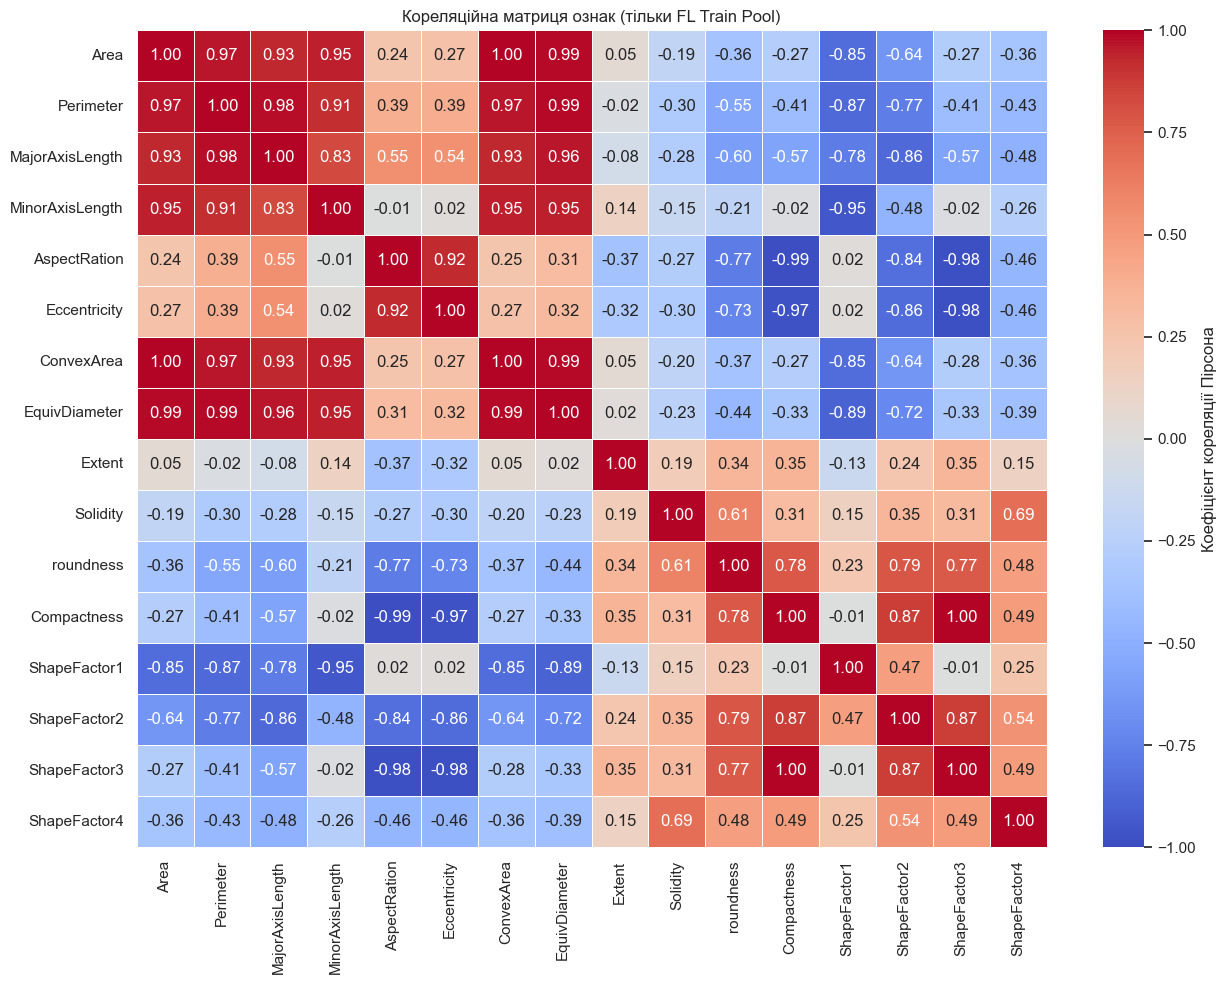

Пар ознак з |r| > 0.95: 15 (із 120 можливих)


,Ознака 1,Ознака 2,r
0,Area,ConvexArea,1.000
1,Compactness,ShapeFactor3,0.999
2,Perimeter,EquivDiameter,0.992
3,AspectRation,Compactness,-0.988
4,ConvexArea,EquivDiameter,0.985
5,Area,EquivDiameter,0.985
6,Eccentricity,ShapeFactor3,-0.981
7,AspectRation,ShapeFactor3,-0.978
8,Perimeter,MajorAxisLength,0.978
9,Eccentricity,Compactness,-0.970


In [15]:
corr = X_pool.corr()

plt.figure(figsize=(13, 10))
sns.heatmap(
    corr, annot=True, fmt=".2f", cmap="coolwarm",
    vmin=-1, vmax=1, linewidths=0.4, center=0,
    cbar_kws={"label": "Коефіцієнт кореляції Пірсона"},
)
plt.title("Кореляційна матриця ознак (тільки FL Train Pool)")
plt.tight_layout()
plt.show()

THR = 0.95
pairs = []
cols = list(corr.columns)
for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        r = corr.iloc[i, j]
        if abs(r) > THR:
            pairs.append((cols[i], cols[j], round(float(r), 3)))

print(f"Пар ознак з |r| > {THR}: {len(pairs)} "
      f"(із {len(cols) * (len(cols) - 1) // 2} можливих)")
display(pd.DataFrame(pairs, columns=["Ознака 1", "Ознака 2", "r"])
          .sort_values("r", key=np.abs, ascending=False)
          .reset_index(drop=True))


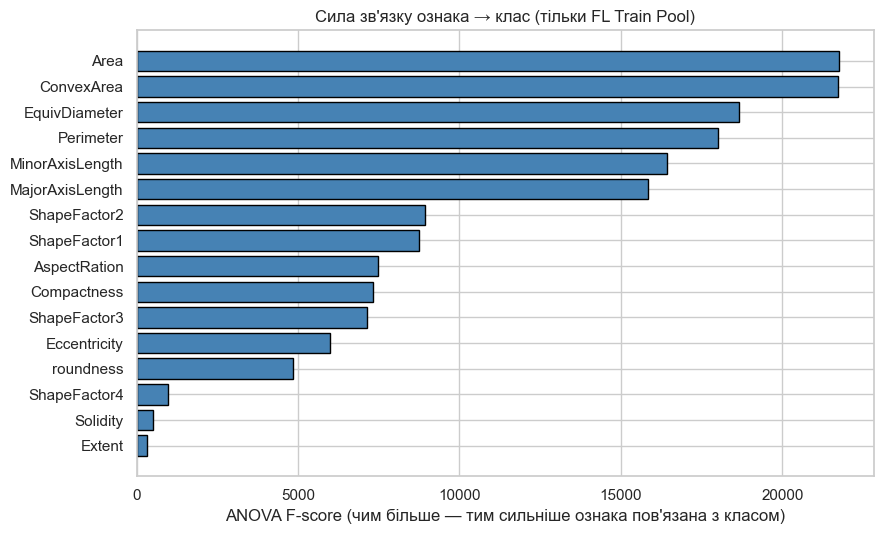

,feature,F_score,p_value
0,Area,21753.037778,0.0
1,ConvexArea,21738.001814,0.0
2,EquivDiameter,18671.713936,0.0
3,Perimeter,18008.483553,0.0
4,MinorAxisLength,16435.746218,0.0
5,MajorAxisLength,15835.908516,0.0
6,ShapeFactor2,8936.976992,0.0
7,ShapeFactor1,8738.330930,0.0
8,AspectRation,7472.172298,0.0
9,Compactness,7331.413851,0.0


In [16]:
from sklearn.feature_selection import f_classif

F, pval = f_classif(X_pool.values, y_pool)
imp = (pd.DataFrame({"feature": num_cols, "F_score": F, "p_value": pval})
         .sort_values("F_score", ascending=False)
         .reset_index(drop=True))

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.barh(imp["feature"][::-1], imp["F_score"][::-1], color="steelblue", edgecolor="black")
ax.set_xlabel("ANOVA F-score (чим більше — тим сильніше ознака пов'язана з класом)")
ax.set_title("Сила зв'язку ознака → клас (тільки FL Train Pool)")
plt.tight_layout()
plt.show()

display(imp.head(20))


,feature,eta2,F_score,VIF
0,Area,0.930,21753,"86,706.9"
1,ConvexArea,0.930,21738,"84,316.2"
2,EquivDiameter,0.919,18672,"312,790.9"
3,Perimeter,0.916,18008,"3,883.6"
4,MinorAxisLength,0.909,16436,"76,681.2"
5,MajorAxisLength,0.906,15836,"87,220.7"
6,ShapeFactor2,0.844,8937,"1,225.1"
7,ShapeFactor1,0.841,8738,611.5
8,AspectRation,0.819,7472,"14,219.1"
9,Compactness,0.817,7331,"288,647.9"


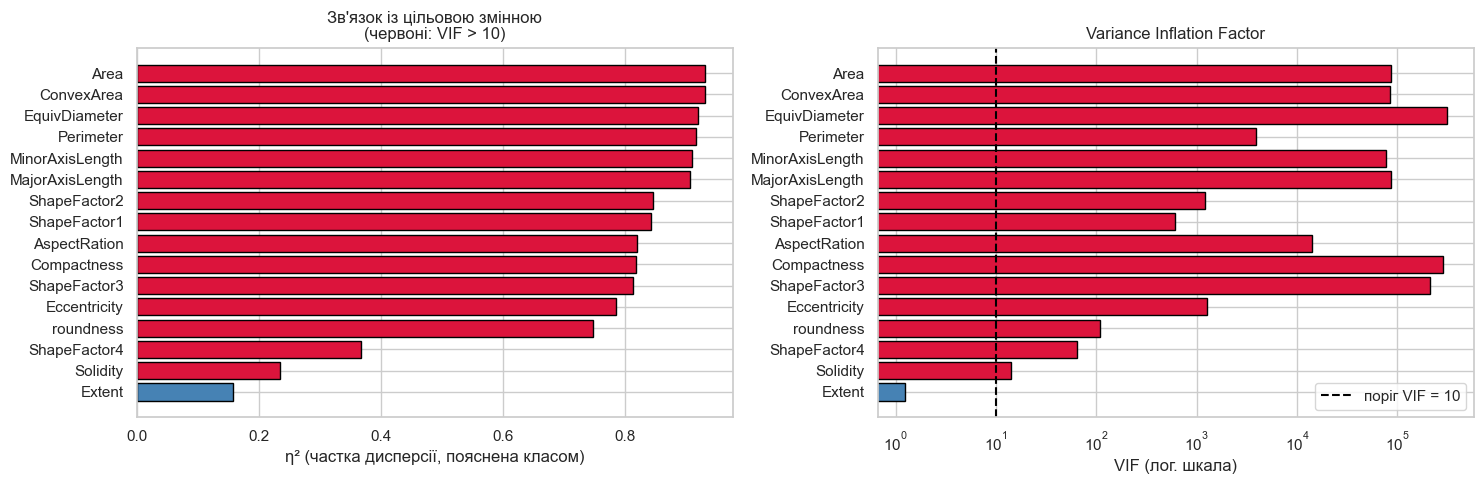

Ознак із VIF > 10: 15 із 16


In [ ]:
def eta_squared(X, y, n_cls):
    gm = X.mean(axis=0)
    ss_between = np.zeros(X.shape[1])
    for c in range(n_cls):
        Xc = X[y == c]
        ss_between += len(Xc) * (Xc.mean(axis=0) - gm) ** 2
    ss_total = ((X - gm) ** 2).sum(axis=0)
    return ss_between / ss_total

eta2 = eta_squared(X_pool.values, y_pool, C)
vif = np.diag(np.linalg.inv(corr.values + 1e-8 * np.eye(corr.shape[0])))  # VIF_j = [R^{-1}]_jj

df_feat = (pd.DataFrame({
    "feature": num_cols,
    "eta2": eta2,
    "F_score": F,
    "VIF": vif,
}).sort_values("eta2", ascending=False).reset_index(drop=True))

display(df_feat.style.format({"eta2": "{:.3f}", "F_score": "{:.0f}", "VIF": "{:,.1f}"}))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
colors_v = ["crimson" if v > 10 else "steelblue" for v in df_feat["VIF"]]
axes[0].barh(df_feat["feature"][::-1], df_feat["eta2"][::-1],
             color=colors_v[::-1], edgecolor="black")
axes[0].set_xlabel("η² (частка дисперсії, пояснена класом)")
axes[0].set_title("Зв'язок із цільовою змінною\n(червоні: VIF > 10)")
axes[1].barh(df_feat["feature"][::-1], df_feat["VIF"][::-1],
             color=colors_v[::-1], edgecolor="black")
axes[1].set_xscale("log")
axes[1].axvline(10, color="black", ls="--", label="поріг VIF = 10")
axes[1].set_xlabel("VIF (лог. шкала)")
axes[1].legend()
axes[1].set_title("Variance Inflation Factor")
plt.tight_layout()
plt.show()

print(f"Ознак із VIF > 10: {(vif > 10).sum()} із {len(vif)}")


**Висновок до η² / VIF.** Велике η² означає, що за цією ознакою класи добре
розходяться; великий VIF — що ознака майже лінійно виражається через інші
(тобто дублює їх). Часто виходить так: ознаки самі по собі сильні, але між
собою сильно корелюють. Тому нижче з пар із |r| > 0.95 лишаємо лише одну
ознаку — ту, у якої більший F-score.


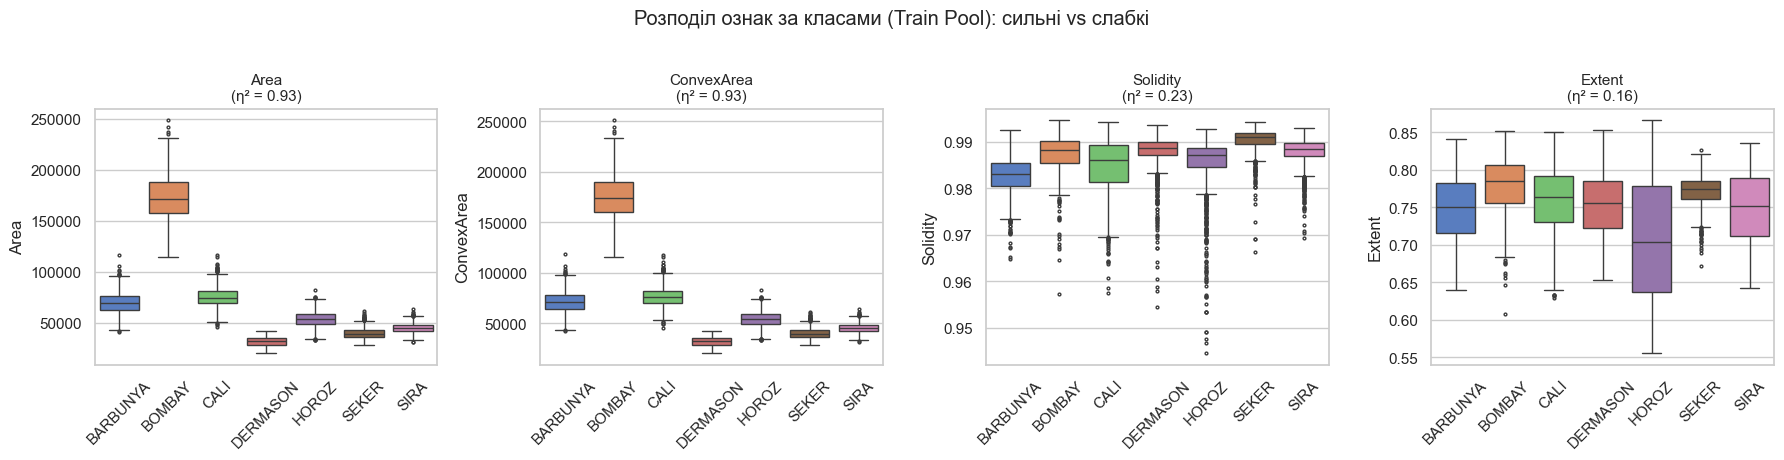

In [ ]:
# Boxplot: дві сильні vs дві слабкі ознаки (за η²) — як класи розходяться
df_pool_plot = X_pool.copy()
df_pool_plot[TARGET] = y_pool_raw

ranked = df_feat["feature"].tolist()
sel_feats = ranked[:2] + ranked[-2:]

fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
for ax, f in zip(axes, sel_feats):
    sns.boxplot(
        data=df_pool_plot, x=TARGET, y=f, order=CLASS_NAMES,
        hue=TARGET, hue_order=CLASS_NAMES, legend=False,
        ax=ax, palette="muted", fliersize=2,
    )
    eta = float(df_feat.loc[df_feat.feature == f, "eta2"].iloc[0])
    ax.set_title(f"{f}\n(η² = {eta:.2f})", fontsize=11)
    ax.tick_params(axis="x", rotation=45)
    ax.set_xlabel("")
plt.suptitle("Розподіл ознак за класами (Train Pool): сильні vs слабкі", y=1.02)
plt.tight_layout()
plt.show()


**Висновок до boxplot.** У сильних ознак "ящики" класів розходяться
помітніше (особливо BOMBAY за розміром), у слабких — сильно перекриваються.
Це інтуїтивне підтвердження таблиці η² / F-score: модель більше виграє від
ознак, де класи реально розділені.


In [19]:
to_drop = set()
for a, b, r in pairs:
    fa = float(imp.loc[imp.feature == a, "F_score"].iloc[0])
    fb = float(imp.loc[imp.feature == b, "F_score"].iloc[0])
    weaker = a if fa < fb else b
    if a not in to_drop and b not in to_drop:
        to_drop.add(weaker)

FEATURES = [c for c in num_cols if c not in to_drop]
print("Викинуто через мультиколінеарність:", sorted(to_drop))
print("Залишилось ознак:", len(FEATURES))
print(FEATURES)

Викинуто через мультиколінеарність: ['Compactness', 'ConvexArea', 'EquivDiameter', 'MinorAxisLength', 'Perimeter', 'ShapeFactor3']
Залишилось ознак: 10
['Area', 'MajorAxisLength', 'AspectRation', 'Eccentricity', 'Extent', 'Solidity', 'roundness', 'ShapeFactor1', 'ShapeFactor2', 'ShapeFactor4']


**Висновок.** На тепловій карті видно яскраві плями — це пари ознак, які
насправді вимірюють майже одне й те саме (площа, опукла площа, еквівалентний
діаметр, периметр — усе це по суті "розмір зерна", тільки порахований трохи
по-різному). Модель від таких дублікатів не ламається, але ваги стають
"хиткими": модель може довільно розподіляти вагу між двома однаковими
ознаками, і від цього трохи важче й довше навчатись. Тому з кожної пари з
|r| > 0.95 ми лишаємо тільки одну ознаку — ту, яка сильніше пов'язана з
класом (більший F-score), а другу викидаємо. І робимо це, дивлячись тільки
на FL Train Pool, а не на тест.

## Масштабування

Використовуємо **стандартизацію**: z = (x - mean) / std.

У федеративному режимі є два коректні підходи. У цій роботі за замовчуванням
використано **спрощений підхід (а)**: скалер навчається на всьому FL Train Pool
до розподілу між клієнтами — це явно частина симуляції, а не реального
федеративного протоколу.

Нижче також реалізовано **підхід (б)** — кожен клієнт рахує локальні
статистики, а сервер агрегує їх зважено за кількістю прикладів. Далі ми
чисельно перевіримо, що обидва підходи дають однакові mean/std (бо зважене
середнє локальних середніх = глобальне середнє).

In [20]:
Xp = X_pool[FEATURES].values.astype(float)
Xv = X_val[FEATURES].values.astype(float)
Xt = X_test[FEATURES].values.astype(float)

mu = Xp.mean(axis=0)
sd = Xp.std(axis=0)
sd[sd == 0] = 1.0   

Xp_s = (Xp - mu) / sd
Xv_s = (Xv - mu) / sd     
Xt_s = (Xt - mu) / sd

print("Середнє train після стандартизації (має бути ~0):", np.round(Xp_s.mean(axis=0)[:5], 6) + 0.0)
print("Std train після стандартизації (має бути ~1):   ", np.round(Xp_s.std(axis=0)[:5], 6))
print("Середнє test  після стандартизації (близьке, але не рівне 0):", np.round(Xt_s.mean(axis=0)[:5], 3))

Середнє train після стандартизації (має бути ~0): [0. 0. 0. 0. 0.]
Std train після стандартизації (має бути ~1):    [1. 1. 1. 1. 1.]
Середнє test  після стандартизації (близьке, але не рівне 0): [ 0.004  0.008  0.006  0.011 -0.013]


In [21]:
def federated_scaler_stats(X, client_indices):
    n_total = sum(len(idx) for idx in client_indices)
    mean_agg = np.zeros(X.shape[1])
    sq_agg = np.zeros(X.shape[1])
    for idx in client_indices:
        Xk = X[idx]
        nk = len(idx)
        mean_agg += nk * Xk.mean(axis=0)
        sq_agg += nk * (Xk ** 2).mean(axis=0)
    mean_agg /= n_total
    var_agg = sq_agg / n_total - mean_agg ** 2
    return mean_agg, np.sqrt(np.maximum(var_agg, 1e-12))

_idx = np.array_split(np.random.permutation(len(Xp)), 5)
mu_fed, sd_fed = federated_scaler_stats(Xp, _idx)
print("Макс. різниця середніх:", np.abs(mu_fed - mu).max())
print("Макс. різниця std:    ", np.abs(sd_fed - sd).max())

Макс. різниця середніх: 1.3322676295501878e-15
Макс. різниця std:     3.2078072836894123e-13


**Висновок.** Різниця між "звичайним" скалером і скалером, зібраним із
локальних статистик клієнтів, вийшла практично нульовою (тільки похибка
округлення). Тобто спрощений варіант (а), який ми використовуємо далі, не
псує результат — а варіант (б) наочно показує, що те саме можна зробити, взагалі
не забираючи в клієнтів жодного рядка сирих даних: досить, щоб кожен клієнт
надіслав лише три числа на ознаку (n, середнє, E[x²]).

## Етап 2. Реалізація багатокласової логістичної регресії на numpy

Нехай $X \in \mathbb{R}^{m \times d}$ — матриця об'єктів, $Y \in \{0,1\}^{m \times C}$ — one-hot мітки,
параметри $W \in \mathbb{R}^{d \times C}$, $b \in \mathbb{R}^{1 \times C}$.

**Лінійна частина (логіти):**
$$Z = XW + b$$

**Softmax (перетворення логітів у ймовірності):**
$$P_{ic} = \frac{\exp(Z_{ic})}{\sum_{j=1}^{C}\exp(Z_{ij})}$$

Для числової стабільності від кожного рядка віднімаємо його максимум:
$\exp(Z - \max Z)$. Математично результат не змінюється (чисельник і знаменник
діляться на ту саму константу), але зникає ризик переповнення `exp`.

**Функція втрат — крос-ентропія з Ridge-регуляризацією:**
$$J(W,b) = -\frac{1}{m}\sum_{i=1}^{m}\sum_{c=1}^{C} Y_{ic}\log P_{ic} + \frac{\lambda}{2}\|W\|_F^2$$

**Градієнти:**
$$\frac{\partial J}{\partial W} = \frac{1}{m}X^\top (P - Y) + \lambda W, \qquad
\frac{\partial J}{\partial b} = \frac{1}{m}\mathbf{1}_m^\top (P - Y)$$

Зверніть увагу, наскільки простий градієнт: різниця "що модель передбачила"
мінус "що є насправді", помножена на входи. Це наслідок того, що softmax і
крос-ентропія — "рідна пара".

In [22]:
def softmax(Z):
    Z = Z - Z.max(axis=1, keepdims=True)
    e = np.exp(Z)
    return e / e.sum(axis=1, keepdims=True)


def one_hot(y, n_classes):
    Y = np.zeros((len(y), n_classes))
    Y[np.arange(len(y)), y] = 1.0
    return Y


class SoftmaxRegression:

    def __init__(self, n_features, n_classes, lr=0.1, lam=0.0, batch_size=128, seed=RANDOM_STATE):
        rng = np.random.default_rng(seed)
        self.W = rng.normal(0, 0.01, size=(n_features, n_classes))
        self.b = np.zeros((1, n_classes))
        self.lr = lr
        self.lam = lam
        self.batch_size = batch_size
        self.n_classes = n_classes
        self.history = {"train_loss": [], "val_loss": [], "val_acc": []}

    def predict_proba(self, X):
        return softmax(X @ self.W + self.b)

    def predict(self, X):
        return np.argmax(self.predict_proba(X), axis=1)

    def loss(self, X, y):
        P = self.predict_proba(X)
        Y = one_hot(y, self.n_classes)
        eps = 1e-12   
        ce = -np.sum(Y * np.log(P + eps)) / X.shape[0]
        return ce + 0.5 * self.lam * np.sum(self.W ** 2)

    def gradients(self, X, y):
        m = X.shape[0]
        P = self.predict_proba(X)
        Y = one_hot(y, self.n_classes)
        diff = P - Y
        gW = X.T @ diff / m + self.lam * self.W 
        gb = diff.sum(axis=0, keepdims=True) / m
        return gW, gb

    def update(self, gW, gb):
        self.W -= self.lr * gW
        self.b -= self.lr * gb

    def fit(self, X, y, epochs=50, X_val=None, y_val=None, seed=RANDOM_STATE, track=True):
        rng = np.random.default_rng(seed)
        m = X.shape[0]
        for ep in range(epochs):
            order = rng.permutation(m)          
            for start in range(0, m, self.batch_size):
                idx = order[start:start + self.batch_size]
                gW, gb = self.gradients(X[idx], y[idx])
                self.update(gW, gb)
            if track:
                self.history["train_loss"].append(self.loss(X, y))
                if X_val is not None:
                    self.history["val_loss"].append(self.loss(X_val, y_val))
                    self.history["val_acc"].append((self.predict(X_val) == y_val).mean())
        return self

    def get_params(self):
        return self.W.copy(), self.b.copy()

    def set_params(self, W, b):
        self.W = W.copy()
        self.b = b.copy()

print("Модель готова.")

Модель готова.


### Перевірка градієнтів (sanity check)

Порівняємо аналітичний градієнт із числовим (кінцеві різниці). Якщо різниця
порядку 1e-7 і менше — формули реалізовані правильно.

In [23]:
def grad_check(model, X, y, n_checks=5, eps=1e-5):
    rng = np.random.default_rng(0)
    gW, gb = model.gradients(X, y)
    errs = []
    for _ in range(n_checks):
        i = rng.integers(model.W.shape[0])
        j = rng.integers(model.W.shape[1])
        old = model.W[i, j]
        model.W[i, j] = old + eps
        l1 = model.loss(X, y)
        model.W[i, j] = old - eps
        l2 = model.loss(X, y)
        model.W[i, j] = old
        num = (l1 - l2) / (2 * eps)
        errs.append(abs(num - gW[i, j]))
    return max(errs)

_m = SoftmaxRegression(Xp_s.shape[1], C, lam=0.01)
print("Максимальна різниця аналітичного і числового градієнта:", grad_check(_m, Xp_s[:500], y_pool[:500]))

Максимальна різниця аналітичного і числового градієнта: 1.6247753142906163e-11


## Етап 3. Централізована базова модель

Навчаємо модель на **всьому FL Train Pool** — це та "стеля", з якою потім
порівнюватимемо федеративні результати. Гіперпараметри (швидкість навчання,
розмір батчу, сила регуляризації) підбираємо **на Global Validation**.
Global Test не чіпаємо до самого кінця.

In [24]:
def evaluate(model, X, y, name=""):
    proba = model.predict_proba(X)
    proba = np.nan_to_num(proba, nan=1.0 / C, posinf=1.0, neginf=0.0)
    proba = np.clip(proba, 1e-12, 1.0)
    proba = proba / proba.sum(axis=1, keepdims=True)
    pred = np.argmax(proba, axis=1)
    return {
        "model": name,
        "accuracy": accuracy_score(y, pred),
        "macro_F1": f1_score(y, pred, average="macro"),
        "balanced_acc": balanced_accuracy_score(y, pred),
        "log_loss": log_loss(y, proba, labels=list(range(C))),
    }


results_grid = []
for lr in [0.05, 0.1, 0.5]:
    for bs in [64, 256]:
        for lam in [0.0, 0.001, 0.01]:
            m = SoftmaxRegression(Xp_s.shape[1], C, lr=lr, lam=lam, batch_size=bs)
            m.fit(Xp_s, y_pool, epochs=40, track=False)
            r = evaluate(m, Xv_s, y_val)
            results_grid.append({"lr": lr, "batch": bs, "lambda": lam,
                                 "val_acc": r["accuracy"], "val_macroF1": r["macro_F1"],
                                 "val_logloss": r["log_loss"]})

grid_df = pd.DataFrame(results_grid).sort_values("val_macroF1", ascending=False)
grid_df.head(10)

,lr,batch,lambda,val_acc,val_macroF1,val_logloss
12,0.50,64,0.000,0.923124,0.930229,0.246878
1,0.05,64,0.001,0.921279,0.927774,0.288567
0,0.05,64,0.000,0.921279,0.927766,0.277331
15,0.50,256,0.000,0.920664,0.927075,0.258894
6,0.10,64,0.000,0.919434,0.925818,0.262306
13,0.50,64,0.001,0.918819,0.925250,0.270759
16,0.50,256,0.001,0.918204,0.924727,0.274692
7,0.10,64,0.001,0.918204,0.924612,0.276750
10,0.10,256,0.001,0.917589,0.923135,0.311913
9,0.10,256,0.000,0.917589,0.923046,0.303142


Обрані гіперпараметри: lr=0.5, batch_size=64, lambda=0.0


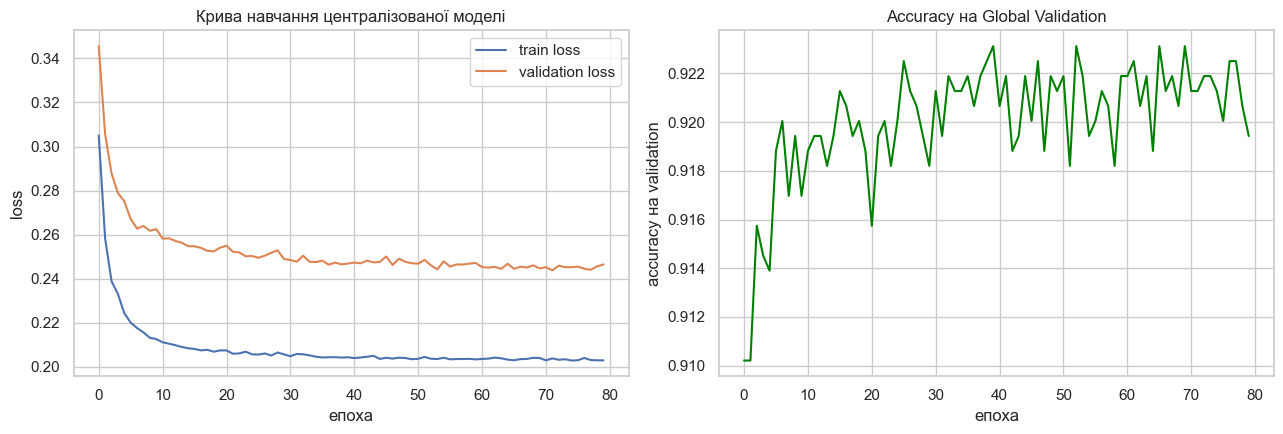

In [25]:
best = grid_df.iloc[0]
BEST_LR = float(best["lr"])
BEST_BS = int(best["batch"])
BEST_LAM = float(best["lambda"])
print(f"Обрані гіперпараметри: lr={BEST_LR}, batch_size={BEST_BS}, lambda={BEST_LAM}")

central = SoftmaxRegression(Xp_s.shape[1], C, lr=BEST_LR, lam=BEST_LAM, batch_size=BEST_BS)
central.fit(Xp_s, y_pool, epochs=80, X_val=Xv_s, y_val=y_val)

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
ax[0].plot(central.history["train_loss"], label="train loss")
ax[0].plot(central.history["val_loss"], label="validation loss")
ax[0].set_xlabel("епоха"); ax[0].set_ylabel("loss"); ax[0].legend()
ax[0].set_title("Крива навчання централізованої моделі")
ax[1].plot(central.history["val_acc"], color="green")
ax[1].set_xlabel("епоха"); ax[1].set_ylabel("accuracy на validation")
ax[1].set_title("Accuracy на Global Validation")
plt.tight_layout(); plt.show()

**Висновок до графіків навчання.** Ліворуч видно, як падає loss на train і
на validation, праворуч — як росте accuracy на валідації. Обидві криві (train
і val) ідуть практично поруч і виходять на плато — це добра ознака: модель
**не перенавчається**. Логічно: у логістичної регресії не так багато
параметрів (усього $d \times C$ ваг), а даних у нас багато, тож "запам'ятати"
шум їй нема з чого. Плато також підказує: після ~50–60 епох додаткове
навчання вже майже нічого не дає — це орієнтир, скільки епох закладати у
федеративному навчанні.

model           Централізована (baseline)
accuracy                         0.917323
macro_F1                         0.929546
balanced_acc                     0.929795
log_loss                         0.229041
dtype: object


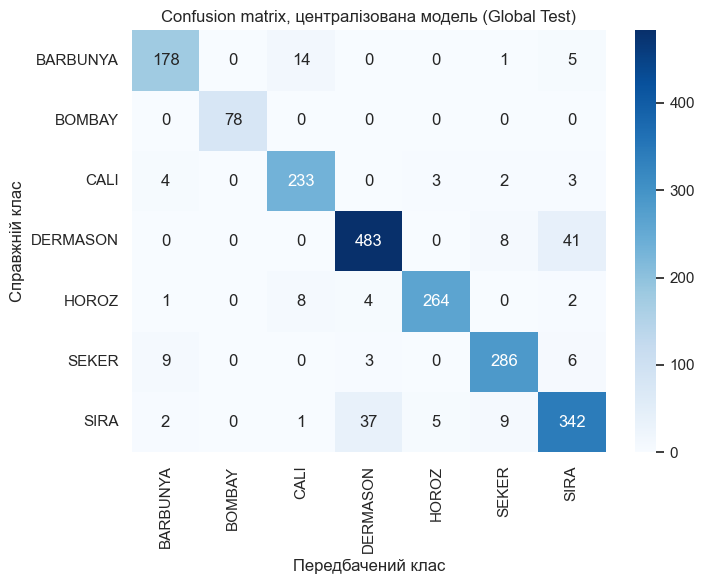

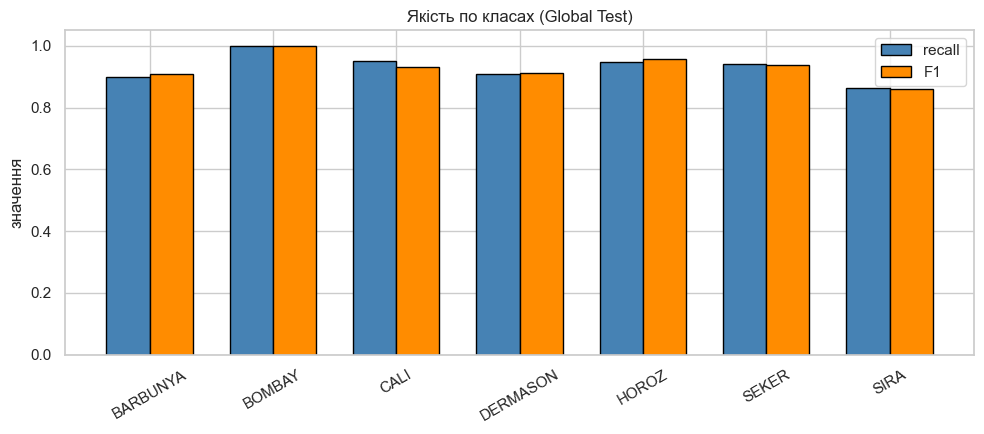

              precision    recall  f1-score   support

    BARBUNYA       0.92      0.90      0.91       198
      BOMBAY       1.00      1.00      1.00        78
        CALI       0.91      0.95      0.93       245
    DERMASON       0.92      0.91      0.91       532
       HOROZ       0.97      0.95      0.96       279
       SEKER       0.93      0.94      0.94       304
        SIRA       0.86      0.86      0.86       396

    accuracy                           0.92      2032
   macro avg       0.93      0.93      0.93      2032
weighted avg       0.92      0.92      0.92      2032



In [ ]:
base_metrics = evaluate(central, Xt_s, y_test, "Централізована (baseline)")
print(pd.Series(base_metrics))

cm = confusion_matrix(y_test, central.predict(Xt_s))
plt.figure(figsize=(7.5, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel("Передбачений клас"); plt.ylabel("Справжній клас")
plt.title("Confusion matrix, централізована модель (Global Test)")
plt.tight_layout(); plt.show()

from sklearn.metrics import precision_recall_fscore_support
pred_test = central.predict(Xt_s)
prec, rec, f1c, support = precision_recall_fscore_support(
    y_test, pred_test, labels=list(range(C)), zero_division=0)

fig, ax = plt.subplots(figsize=(10, 4.5))
x = np.arange(C)
w = 0.35
ax.bar(x - w/2, rec, width=w, label="recall", color="steelblue", edgecolor="black")
ax.bar(x + w/2, f1c, width=w, label="F1", color="darkorange", edgecolor="black")
ax.set_xticks(x)
ax.set_xticklabels(CLASS_NAMES, rotation=30)
ax.set_ylim(0, 1.05)
ax.set_ylabel("значення")
ax.set_title("Якість по класах (Global Test)")
ax.legend()
plt.tight_layout()
plt.show()

print(classification_report(y_test, pred_test, target_names=CLASS_NAMES))


**Висновок до confusion matrix.** По діагоналі — правильні відповіді,
все інше — помилки. Видно, які сорти модель плутає між собою: зазвичай це ті,
що схожі за розміром і формою (наприклад SIRA і DERMASON). А сорт з дуже
особливою формою (BOMBAY — найбільші зерна) модель майже не плутає ні з чим —
це видно і на стовпчиках recall/F1 по класах. Ось чому macro-F1 нижчий за
accuracy: усі помилки "зібрані" у кількох схожих класах, а не розкидані
рівномірно.

### Додатково: як λ (сила Ridge-регуляризації) впливає на модель

Вище ми вже підбирали λ разом з lr і batch_size у одному переборі (grid search),
але тут хочеться подивитись саме на **сам ефект регуляризації** окремо: як
змінюються ваги моделі і якість, якщо збільшувати λ від 0 до дуже великого
значення. Фіксуємо lr і batch_size (ті, що вже обрали), і міняємо тільки λ.

In [ ]:
lambdas = [0.0, 0.001, 0.01, 0.1, 1.0, 5.0, 20.0]
lam_rows = []
for lam in lambdas:
    lr_eff = BEST_LR if lam <= 0.1 else min(BEST_LR, 0.1 / lam)
    m = SoftmaxRegression(Xp_s.shape[1], C, lr=lr_eff, lam=lam, batch_size=BEST_BS)
    m.fit(Xp_s, y_pool, epochs=40, track=False)
    r = evaluate(m, Xv_s, y_val)
    lam_rows.append({"lambda": lam, "lr_eff": lr_eff, "val_acc": r["accuracy"],
                     "val_logloss": r["log_loss"], "norm_W": np.linalg.norm(m.W)})

lam_df = pd.DataFrame(lam_rows)
lam_df

,lambda,lr_eff,val_acc,val_logloss,norm_W
0,0.000,0.500,0.923124,0.246878,15.898064
1,0.001,0.500,0.918819,0.270759,10.252568
2,0.010,0.500,0.909594,0.388214,5.542706
3,0.100,0.500,0.811808,0.769939,2.273132
4,1.000,0.100,0.460025,1.379055,0.609296
5,5.000,0.020,0.267528,1.688619,0.166770
6,20.000,0.005,0.261993,1.793484,0.045579


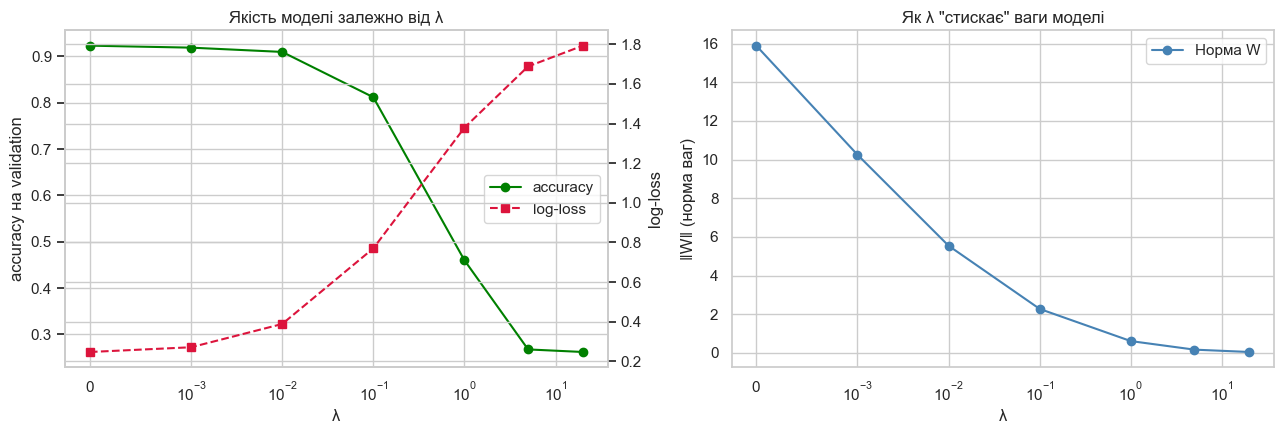

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))

ax[0].plot(lam_df["lambda"], lam_df["val_acc"], "o-", color="green", label="accuracy")
ax[0].set_xscale("symlog", linthresh=0.001)
ax[0].set_xlabel("λ"); ax[0].set_ylabel("accuracy на validation")

ax2 = ax[0].twinx()
ax2.plot(lam_df["lambda"], lam_df["val_logloss"], "s--", color="crimson", label="log-loss")
ax2.set_ylabel("log-loss")
ax[0].set_title("Якість моделі залежно від λ")

lines_1, labels_1 = ax[0].get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax[0].legend(lines_1 + lines_2, labels_1 + labels_2, loc="center right")

ax[1].plot(lam_df["lambda"], lam_df["norm_W"], "o-", color="steelblue", label="Норма W")
ax[1].set_xscale("symlog", linthresh=0.001)
ax[1].set_xlabel("λ"); ax[1].set_ylabel("‖W‖ (норма ваг)")
ax[1].set_title('Як λ "стискає" ваги моделі')

ax[1].legend(loc="best")

plt.tight_layout()
plt.show()

**Висновок.** Правий графік показує саму суть Ridge: чим більша λ, тим
менша норма ваг ‖W‖ — регуляризація буквально стискає ваги до нуля. Лівий
графік показує ціну цього: поки λ мала, якість майже не змінюється (наша
модель і так не перенавчається — вона надто проста, щоб "запам'ятовувати"
шум, як ми вже бачили на кривих навчання). А от при дуже великій λ (наприклад
20) модель починає **недонавчатись** — ваги настільки притиснуті до нуля, що
модель вже не може добре розділити класи, і accuracy падає, а log-loss росте.
Тобто оптимальне λ — десь посередині, і саме тому ми підбираємо його на
Global Validation, а не беремо навмання.

## Етап 4. Розподіл даних між клієнтами та сервером

### Архітектура

| Учасник | Має доступ до | НЕ має доступу до |
|---|---|---|
| **Сервер (агрегатор)** | Global Test, Global Validation, ваги, які надіслали клієнти | сирих даних клієнтів, локальних вибірок |
| **Клієнт k** | власна локальна вибірка $D_k$ | Global Test, Global Validation, даних і ваг інших клієнтів |

Кожен приклад із FL Train Pool потрапляє **рівно до одного** клієнта.
Розподіл відтворюваний (фіксоване зерно).

### Два типи розподілу

**IID** — перемішуємо дані й ділимо на K приблизно рівних стратифікованих частин:
у кожного клієнта пропорції класів такі самі, як глобальні.

**Non-IID (Діріхле)** — для кожного класу $c$ генеруємо пропорції
$(p_{1c},\dots,p_{Kc}) \sim \mathrm{Dirichlet}(\alpha,\dots,\alpha)$ і роздаємо
приклади цього класу клієнтам згідно з цими пропорціями. Параметр $\alpha$
керує неоднорідністю: велике $\alpha$ → майже IID, мале $\alpha$ → у клієнтів
"свої" класи.

In [ ]:
def split_iid(y, K, seed=RANDOM_STATE):
    rng = np.random.default_rng(seed)
    clients = [[] for _ in range(K)]
    for c in np.unique(y):
        idx = np.where(y == c)[0]
        rng.shuffle(idx)
        parts = np.array_split(idx, K)
        for k in range(K):
            clients[k].extend(parts[k].tolist())
    return [np.array(sorted(c)) for c in clients]


def split_dirichlet(y, K, alpha, seed=RANDOM_STATE, min_size=10):
    rng = np.random.default_rng(seed)
    while True:
        clients = [[] for _ in range(K)]
        for c in np.unique(y):
            idx = np.where(y == c)[0]
            rng.shuffle(idx)
            p = rng.dirichlet(alpha * np.ones(K))
            cuts = (np.cumsum(p) * len(idx)).astype(int)[:-1]
            for k, part in enumerate(np.split(idx, cuts)):
                clients[k].extend(part.tolist())
        sizes = [len(c) for c in clients]
        if min(sizes) >= min_size:      
            break
    return [np.array(sorted(c)) for c in clients]


def describe_split(client_idx, y, title=""):
    K = len(client_idx)
    table = np.zeros((K, C), dtype=int)
    for k, idx in enumerate(client_idx):
        for c in range(C):
            table[k, c] = int((y[idx] == c).sum())
    dfc = pd.DataFrame(table, columns=CLASS_NAMES,
                       index=[f"client {k}" for k in range(K)])
    dfc["ВСЬОГО"] = dfc.sum(axis=1)
    print(title)
    print(dfc)
    print("Мінімальний розмір клієнта:", dfc["ВСЬОГО"].min())
    return dfc


def plot_split(dfc, title):
    fig, ax = plt.subplots(1, 3, figsize=(16, 4.5))
    cls_part = dfc.drop(columns="ВСЬОГО")
    sns.heatmap(cls_part, annot=True, fmt="d", cmap="YlGnBu", ax=ax[0])
    ax[0].set_title(f"Кількість прикладів класу у клієнта\n{title}")

    bottom = np.zeros(len(dfc))
    palette = sns.color_palette("tab10", C)
    for j, col in enumerate(CLASS_NAMES):
        ax[1].bar(dfc.index, dfc[col].values, bottom=bottom,
                  color=palette[j], edgecolor="black", linewidth=0.3, label=col)
        bottom += dfc[col].values
    ax[1].set_title("Склад класів у клієнтів (stacked)")
    ax[1].set_ylabel("кількість прикладів")
    ax[1].tick_params(axis="x", rotation=30)
    ax[1].legend(fontsize=7, ncol=2, loc="upper right")

    dfc["ВСЬОГО"].plot(kind="bar", ax=ax[2], color="darkorange", edgecolor="black")
    ax[2].set_title("Загальна кількість прикладів у клієнта")
    ax[2].set_ylabel("n_k")
    ax[2].tick_params(axis="x", rotation=30)
    plt.tight_layout()
    plt.show()

print("Функції розподілу готові.")


Функції розподілу готові.


=== IID-розподіл, K=5 ===
          BARBUNYA  BOMBAY  CALI  DERMASON  HOROZ  SEKER  SIRA  ВСЬОГО
client 0       193      77   238       518    272    296   385    1979
client 1       193      76   238       518    272    296   385    1978
client 2       193      76   238       518    272    296   385    1978
client 3       193      76   238       517    271    296   385    1976
client 4       193      76   237       517    271    296   384    1974
Мінімальний розмір клієнта: 1974


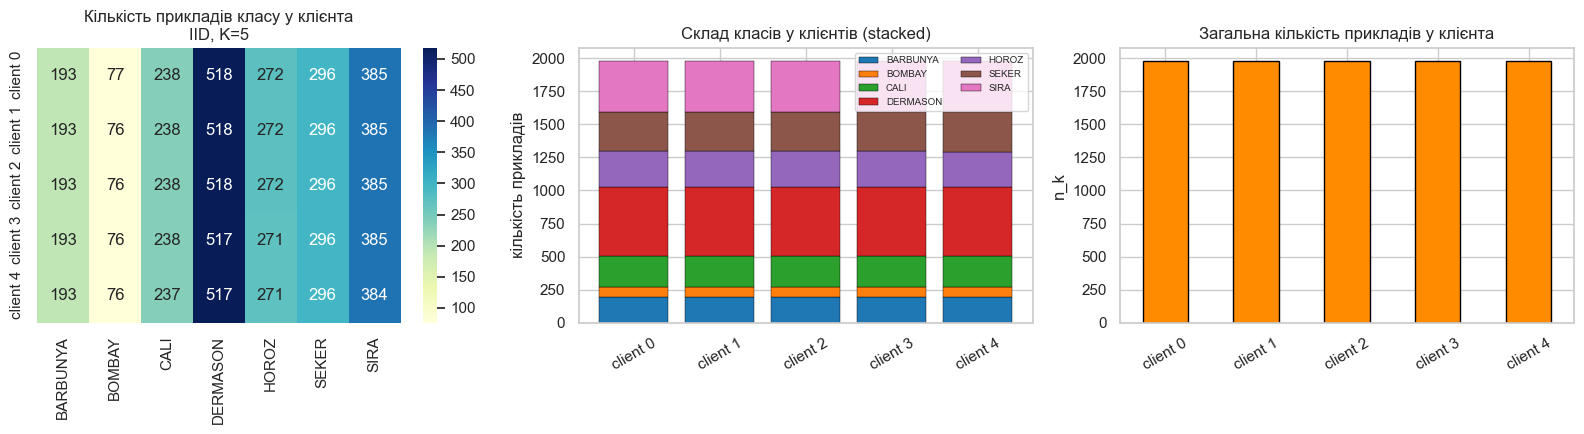

In [30]:
K = 5
iid_idx = split_iid(y_pool, K)
dfc_iid = describe_split(iid_idx, y_pool, f"=== IID-розподіл, K={K} ===")
plot_split(dfc_iid, f"IID, K={K}")


=== Non-IID, alpha=5.0, K=5 ===
          BARBUNYA  BOMBAY  CALI  DERMASON  HOROZ  SEKER  SIRA  ВСЬОГО
client 0        98      62   348       354    256    262   353    1733
client 1       207      61   125       424    306    400   471    1994
client 2       229      68   344       515    329    334   277    2096
client 3       143     111   111       528    198    222   317    1630
client 4       288      79   261       767    269    262   506    2432
Мінімальний розмір клієнта: 1630


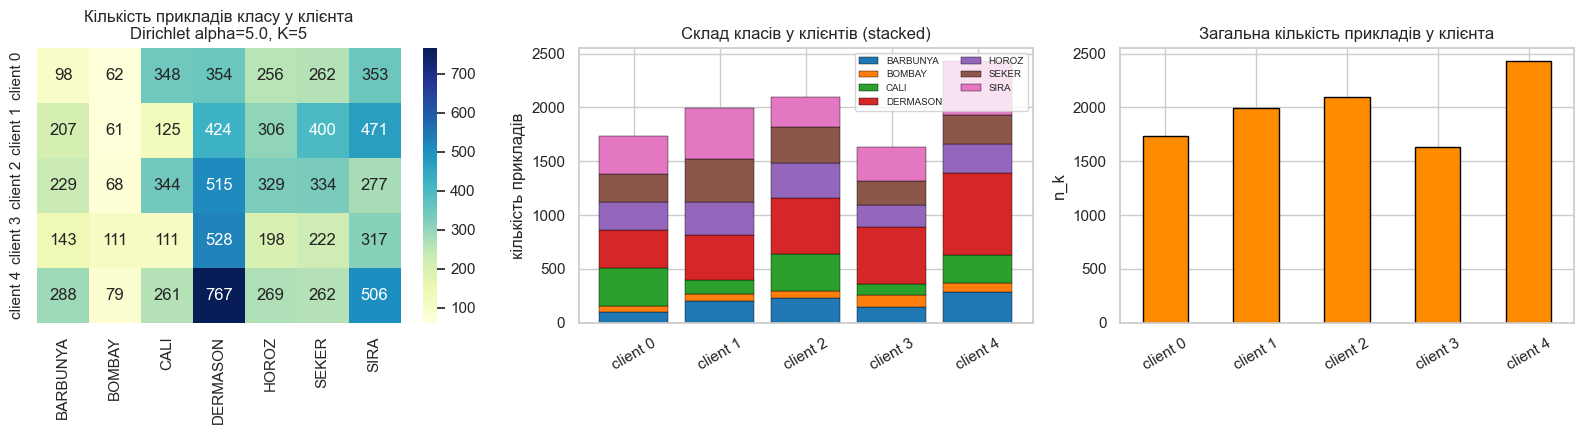


=== Non-IID, alpha=1.0, K=5 ===
          BARBUNYA  BOMBAY  CALI  DERMASON  HOROZ  SEKER  SIRA  ВСЬОГО
client 0       606      38   215       293    331      2   805    2290
client 1        73     186   404       515    170     25   399    1772
client 2       117     107   203      1502    301     14     1    2245
client 3       106      46   160        30     69    861    54    1326
client 4        63       4   207       248    487    578   665    2252
Мінімальний розмір клієнта: 1326


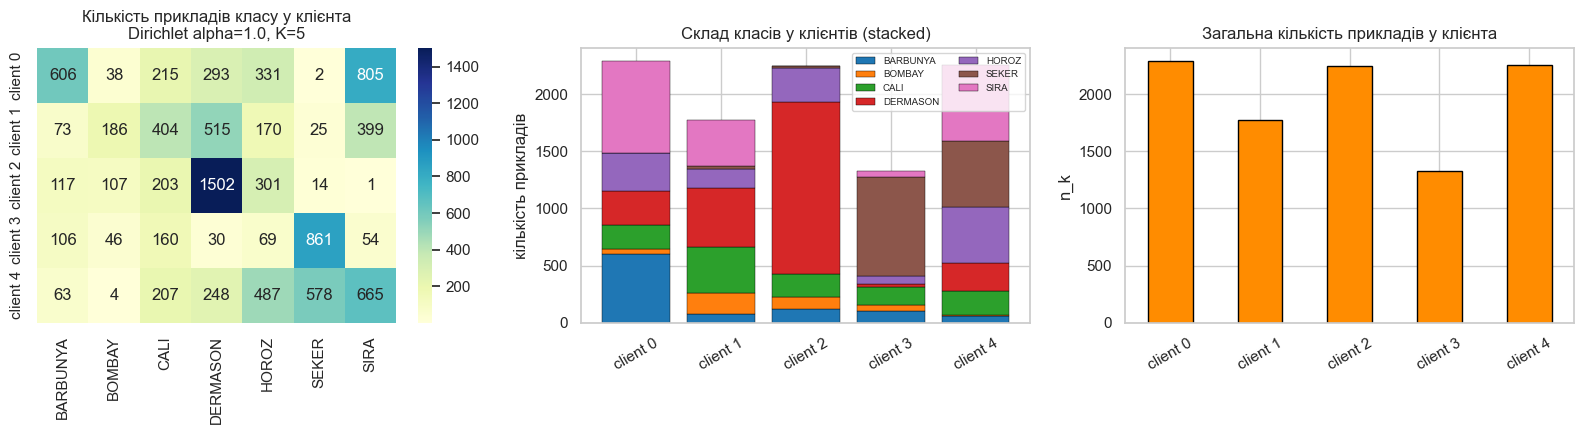


=== Non-IID, alpha=0.3, K=5 ===
          BARBUNYA  BOMBAY  CALI  DERMASON  HOROZ  SEKER  SIRA  ВСЬОГО
client 0       116     239     1       779    136    175     0    1446
client 1       848     124     1         8    675   1159    36    2851
client 2         0       2    36      1771    317      8   167    2301
client 3         0       5    92         2    229     11    39     378
client 4         1      11  1059        28      1    127  1682    2909
Мінімальний розмір клієнта: 378


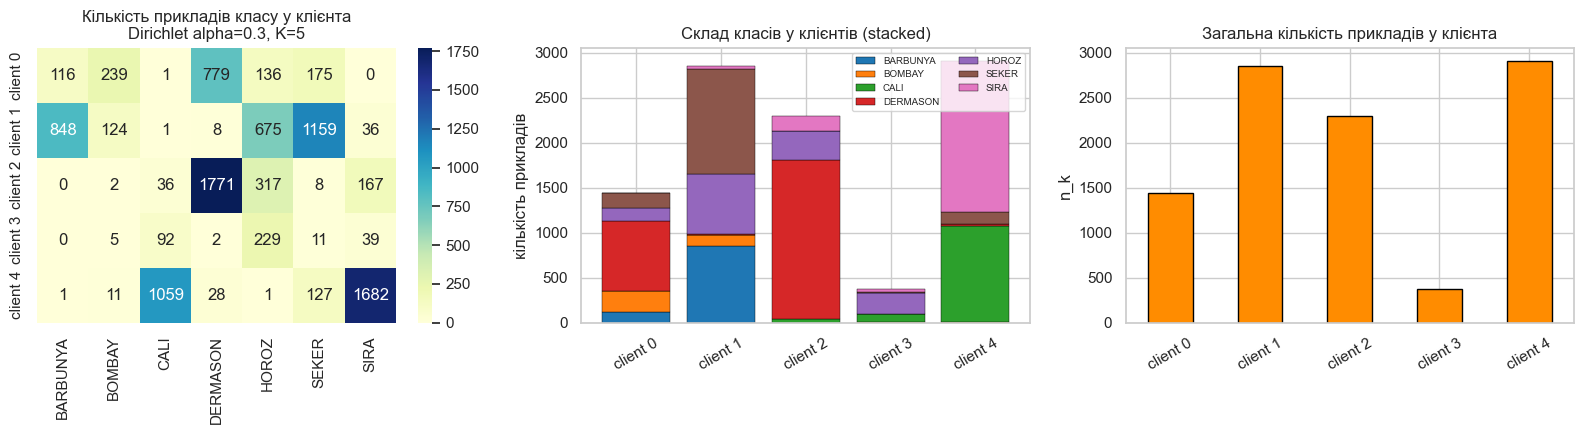

In [31]:
for alpha in [5.0, 1.0, 0.3]:
    idx_a = split_dirichlet(y_pool, K, alpha)
    dfc_a = describe_split(idx_a, y_pool, f"\n=== Non-IID, alpha={alpha}, K={K} ===")
    plot_split(dfc_a, f"Dirichlet alpha={alpha}, K={K}")

**Висновок до візуалізацій розподілу.** На теплових картах рядок — це клієнт,
стовпець — клас, а число в клітинці — скільки прикладів цього класу дісталось
цьому клієнту.

* При **IID** усі рядки виглядають майже однаково і схожі на загальний
  розподіл по всьому датасету — це "чесний" випадок, кожен клієнт бачить
  приблизно ту саму задачу, що й усі інші.
* При **alpha = 5** картина ще дуже схожа на IID, є тільки невеликі перекоси.
* При **alpha = 1** перекоси вже помітні неозброєним оком: у якогось клієнта
  одного класу вдвічі-втричі більше, ніж в іншого.
* При **alpha = 0.3** з'являються майже порожні клітинки — деякі клієнти
  практично не бачили певних класів узагалі, а розміри клієнтів (скільки в
  кого всього прикладів) стають дуже різними.

Чому це погано для глобальної моделі: якщо клієнт майже не бачив якийсь клас,
його локальна модель просто не вчиться його розпізнавати і "тягне" у бік тих
класів, які в неї є. Кожен клієнт по суті вчить трохи іншу задачу, і коли ми
усереднюємо ці різні моделі, результат виходить гірший, ніж якби всі дані
навчались разом централізовано. До того ж, коли в одних клієнтів прикладів
набагато більше, ніж в інших, вони й так сильніше "тягнуть" глобальну модель
на себе (бо FedAvg зважує за $n_k$), і це ще додає перекосу.

## Етап 5. Симуляція федеративного навчання (FedAvg)

**Алгоритм:**
1. Сервер ініціалізує глобальну модель $w^0$.
2. На раунді $t$ сервер обирає підмножину клієнтів $S_t$ і надсилає їм $w^t$.
3. Кожен клієнт навчає модель E локальних епох на своїх даних $D_k$.
4. Клієнт повертає лише параметри $w_k^{t+1}$ (сирі дані не передаються).
5. Сервер агрегує зважено за кількістю прикладів:
$$w^{t+1} = \sum_{k \in S_t} \frac{n_k}{\sum_{j \in S_t} n_j}\, w_k^{t+1}$$
6. Глобальна модель оцінюється на Global Validation.

**Питання: чому зважувати за $n_k$?** Простими словами: клієнт із 3000
прикладів "знає" про задачу набагато більше, ніж клієнт зі 100 прикладами,
тож логічно, щоб і в підсумковій моделі його внесок був більшим. По суті
FedAvg намагається імітувати те, що було б, якби ми зібрали всі дані в одному
місці й навчили одну модель — а там кожен приклад мав би однакову вагу,
незалежно від того, у якого клієнта він опинився. Якщо ж узяти **просте
середнє** (без урахування $n_k$), то маленький клієнт з випадковою і, можливо,
"кривою" вибіркою буде впливати на глобальну модель так само сильно, як
великий і надійний клієнт. Це додає шуму і може зіпсувати якість. Просте
середнє нічим не гірше зваженого лише тоді, коли у всіх клієнтів приблизно
однакова кількість прикладів — тоді ці два варіанти майже збігаються.

In [32]:
def fedavg(client_idx, X, y, X_val, y_val, rounds=30, local_epochs=1,
           lr=0.1, lam=0.0, batch_size=64, client_frac=1.0, seed=RANDOM_STATE):
    rng = np.random.default_rng(seed)
    K = len(client_idx)
    d = X.shape[1]

    global_model = SoftmaxRegression(d, C, lr=lr, lam=lam, batch_size=batch_size, seed=seed)
    history = {"val_acc": [], "val_loss": [], "val_macroF1": []}

    for t in range(rounds):
        n_sel = max(1, int(round(client_frac * K)))
        S = rng.choice(K, size=n_sel, replace=False)

        Wg, bg = global_model.get_params()
        local_W, local_b, local_n = [], [], []

        for k in S:  
            idx = client_idx[k]
            local = SoftmaxRegression(d, C, lr=lr, lam=lam, batch_size=batch_size, seed=seed)
            local.set_params(Wg, bg)                       
            local.fit(X[idx], y[idx], epochs=local_epochs, track=False, seed=seed + t)
            Wk, bk = local.get_params()
            local_W.append(Wk); local_b.append(bk); local_n.append(len(idx))

        n_tot = sum(local_n)
        W_new = sum((n / n_tot) * Wk for n, Wk in zip(local_n, local_W))
        b_new = sum((n / n_tot) * bk for n, bk in zip(local_n, local_b))
        global_model.set_params(W_new, b_new)

        pv = global_model.predict_proba(X_val)
        pred = np.argmax(pv, axis=1)
        history["val_acc"].append(accuracy_score(y_val, pred))
        history["val_loss"].append(log_loss(y_val, pv, labels=list(range(C))))
        history["val_macroF1"].append(f1_score(y_val, pred, average="macro"))

    return global_model, history

print("FedAvg готовий.")

FedAvg готовий.


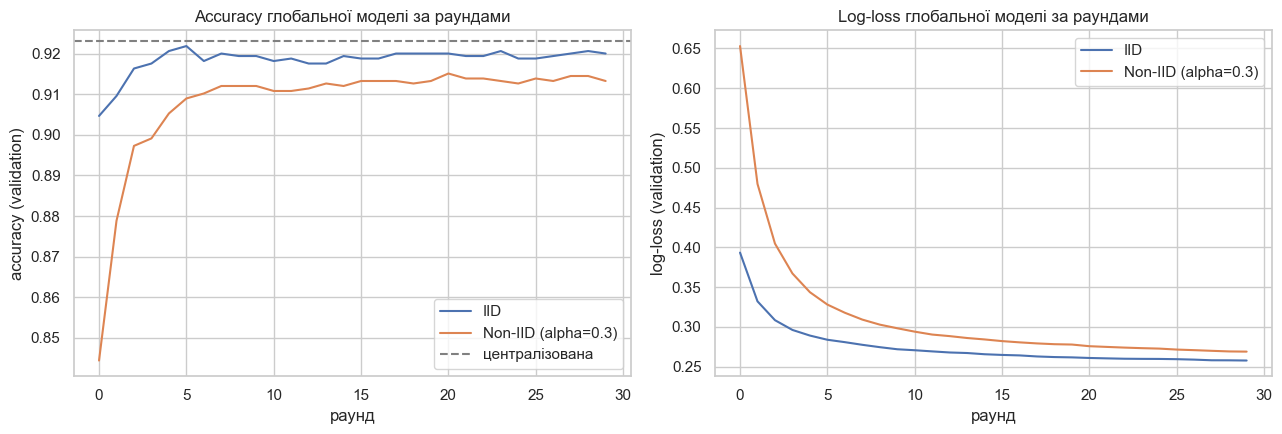

In [33]:
ROUNDS = 30
E_DEFAULT = 3

fed_iid, hist_iid = fedavg(iid_idx, Xp_s, y_pool, Xv_s, y_val,
                           rounds=ROUNDS, local_epochs=E_DEFAULT,
                           lr=BEST_LR, lam=BEST_LAM, batch_size=BEST_BS)

noniid_idx = split_dirichlet(y_pool, K, alpha=0.3)
fed_noniid, hist_noniid = fedavg(noniid_idx, Xp_s, y_pool, Xv_s, y_val,
                                 rounds=ROUNDS, local_epochs=E_DEFAULT,
                                 lr=BEST_LR, lam=BEST_LAM, batch_size=BEST_BS)

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
ax[0].plot(hist_iid["val_acc"], label="IID")
ax[0].plot(hist_noniid["val_acc"], label="Non-IID (alpha=0.3)")
ax[0].axhline(max(central.history["val_acc"]), ls="--", c="gray", label="централізована")
ax[0].set_xlabel("раунд"); ax[0].set_ylabel("accuracy (validation)"); ax[0].legend()
ax[0].set_title("Accuracy глобальної моделі за раундами")
ax[1].plot(hist_iid["val_loss"], label="IID")
ax[1].plot(hist_noniid["val_loss"], label="Non-IID (alpha=0.3)")
ax[1].set_xlabel("раунд"); ax[1].set_ylabel("log-loss (validation)"); ax[1].legend()
ax[1].set_title("Log-loss глобальної моделі за раундами")
plt.tight_layout(); plt.show()

**Висновок до графіків навчання FedAvg.** Тут по осі X — не епохи, а раунди
зв'язку: один раунд = сервер розіслав модель → клієнти локально повчились →
надіслали ваги назад → сервер їх усереднив. IID-крива росте плавно і досить
швидко наближається до рівня централізованої моделі (сіра пунктирна лінія).
Non-IID-крива росте повільніше, помітно "смикається" вгору-вниз (бо кожен
раунд локальні моделі тягнуть у трохи різні боки) і в підсумку виходить на
нижче плато. Ось цей розрив між двома кривими і є наочна "ціна", яку ми
платимо за те, що дані в клієнтів різні.

## Етап 6. Порівняння локальних, глобальної та централізованої моделей

Локальні моделі навчаємо з нуля тільки на даних одного клієнта (без обміну
вагами) і оцінюємо їх на тому самому Global Test, що й решту моделей.

In [34]:
def train_local_models(client_idx, X, y, epochs=30):
    models = []
    for idx in client_idx:
        m = SoftmaxRegression(X.shape[1], C, lr=BEST_LR, lam=BEST_LAM, batch_size=BEST_BS)
        m.fit(X[idx], y[idx], epochs=epochs, track=False)
        models.append(m)
    return models


rows = []
local_models = train_local_models(noniid_idx, Xp_s, y_pool)
for k, m in enumerate(local_models):
    r = evaluate(m, Xt_s, y_test, f"Локальна модель клієнта {k} (n={len(noniid_idx[k])})")
    rows.append(r)

rows.append(evaluate(fed_noniid, Xt_s, y_test, "Глобальна FedAvg (Non-IID alpha=0.3)"))
rows.append(evaluate(fed_iid, Xt_s, y_test, "Глобальна FedAvg (IID)"))
rows.append(base_metrics)

comp = pd.DataFrame(rows).set_index("model").round(4)
comp

,accuracy,macro_F1,balanced_acc,log_loss
model,,,,
Локальна модель клієнта 0 (n=1446),0.6688,0.5732,0.6988,1.6266
Локальна модель клієнта 1 (n=2851),0.5507,0.5368,0.6516,1.4782
Локальна модель клієнта 2 (n=2301),0.7072,0.5537,0.5845,0.9926
Локальна модель клієнта 3 (n=378),0.5984,0.5551,0.6457,1.3694
Локальна модель клієнта 4 (n=2909),0.5699,0.5077,0.5809,2.2829
Глобальна FedAvg (Non-IID alpha=0.3),0.9129,0.9270,0.9288,0.2525
Глобальна FedAvg (IID),0.9163,0.9289,0.9286,0.2351
Централізована (baseline),0.9173,0.9295,0.9298,0.2290


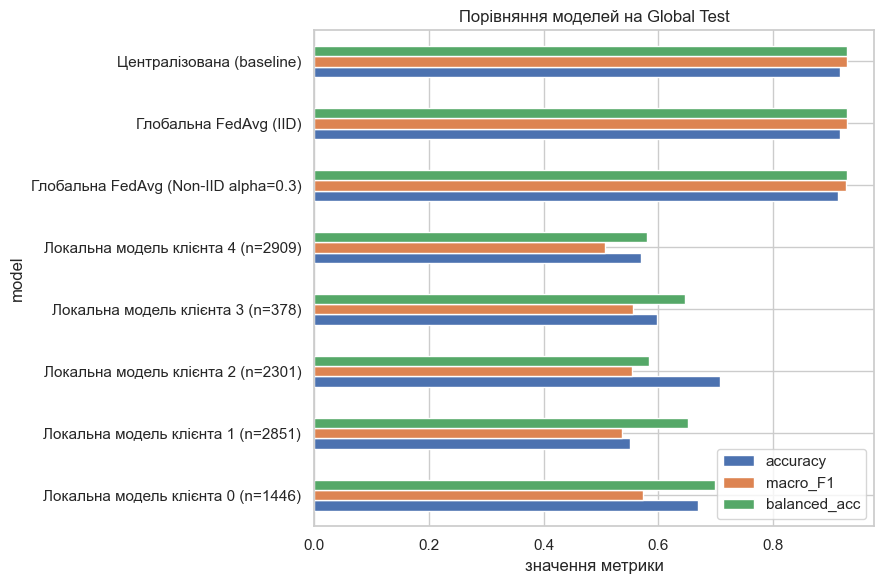

In [35]:
comp[["accuracy", "macro_F1", "balanced_acc"]].plot(kind="barh", figsize=(9, 6))
plt.title("Порівняння моделей на Global Test")
plt.xlabel("значення метрики")
plt.tight_layout(); plt.show()

**Висновок до таблиці та графіка.** Що бачимо:

* **локальні моделі** — найслабші, особливо в тих клієнтів, у кого мала або
  дуже перекошена вибірка. Така модель просто ніколи не бачила якийсь клас і
  тому не вміє його передбачати — macro-F1 і balanced accuracy в неї падають
  дуже сильно (а от accuracy може виглядати не так вже й погано — ще один
  привід не довіряти самій лише accuracy);
* **глобальна FedAvg-модель** значно краща за будь-яку окрему локальну — і
  саме в цьому весь сенс федеративного навчання: кожен клієнт отримує модель,
  кращу за ту, яку він міг би навчити сам, і при цьому нікому не віддає своїх
  даних;
* **централізована модель** залишається найкращою (або майже нарівні з
  IID-варіантом FedAvg) — це наша "стеля", бо вона одразу бачить усі дані
  разом, без жодних втрат на усередненні.

Відповідаючи на питання з завдання: так, глобальна модель **може** бути
гіршою за централізовану (і при Non-IID вона зазвичай трохи гірша). Також
теоретично вона може бути гіршою навіть за окрему локальну модель — але
тільки якщо оцінювати ту локальну модель на **її власних** даних (там вона
"заточена" саме під ці кілька класів і може виграти). А от на спільному
Global Test, який однаковий для всіх, глобальна модель майже завжди виграє в
будь-якої локальної.

## Експеримент 1. Вплив неоднорідності даних (alpha)

In [36]:
alphas = [5.0, 1.0, 0.3]
alpha_rows, alpha_hist = [], {}

for a in alphas:
    idx_a = split_dirichlet(y_pool, K, alpha=a)
    m_a, h_a = fedavg(idx_a, Xp_s, y_pool, Xv_s, y_val, rounds=ROUNDS,
                      local_epochs=E_DEFAULT, lr=BEST_LR, lam=BEST_LAM, batch_size=BEST_BS)
    alpha_hist[a] = h_a
    r = evaluate(m_a, Xt_s, y_test, f"FedAvg alpha={a}")
    r["alpha"] = a
    alpha_rows.append(r)

alpha_df = pd.DataFrame(alpha_rows).set_index("alpha").round(4)
alpha_df

,model,accuracy,macro_F1,balanced_acc,log_loss
alpha,,,,,
5.0,FedAvg alpha=5.0,0.9173,0.9296,0.9294,0.2357
1.0,FedAvg alpha=1.0,0.9129,0.9246,0.9237,0.2431
0.3,FedAvg alpha=0.3,0.9129,0.9270,0.9288,0.2525


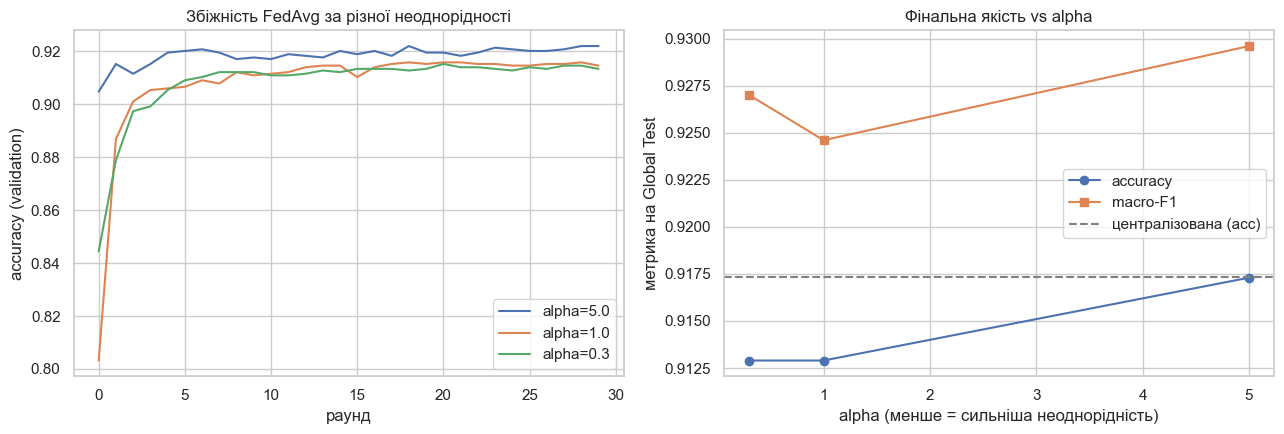

In [37]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
for a in alphas:
    ax[0].plot(alpha_hist[a]["val_acc"], label=f"alpha={a}")
ax[0].set_xlabel("раунд"); ax[0].set_ylabel("accuracy (validation)")
ax[0].set_title("Збіжність FedAvg за різної неоднорідності"); ax[0].legend()

ax[1].plot(alpha_df.index, alpha_df["accuracy"], "o-", label="accuracy")
ax[1].plot(alpha_df.index, alpha_df["macro_F1"], "s-", label="macro-F1")
ax[1].axhline(base_metrics["accuracy"], ls="--", c="gray", label="централізована (acc)")
ax[1].set_xlabel("alpha (менше = сильніша неоднорідність)")
ax[1].set_ylabel("метрика на Global Test")
ax[1].set_title("Фінальна якість vs alpha"); ax[1].legend()
plt.tight_layout(); plt.show()

**Висновок.** Правий графік показує головне: чим менша alpha (тобто чим
сильніша неоднорідність), тим нижча фінальна якість глобальної моделі і тим
більший розрив із централізованою моделлю (сіра пунктирна лінія). Лівий
графік показує, *чому* так відбувається: при малій alpha крива навчання
нерівна, з просіданнями — кожен раунд локальні моделі трохи "тягнуть ковдру
на себе" в різні боки, і після усереднення виходить компроміс, який не є
по-справжньому хорошим рішенням ні для кого.

**Простими словами, чому Non-IID шкодить федеративному навчанню.** FedAvg по
суті сподівається, що середнє з кількох локальних моделей буде приблизно тим
самим, що й модель, навчена одразу на всіх даних разом. Це працює добре, коли
у всіх клієнтів більш-менш однакові дані (IID) — тоді кожна локальна модель
рухається приблизно в тому самому напрямку. А коли дані дуже різні (Non-IID),
кожен клієнт навчається розв'язувати трохи *свою* задачу і рухається у *свій*
локальний оптимум. Коли ми потім усереднюємо ваги кількох моделей, які
"розбіглись" у різні сторони, результат — це щось посередині, що не є
насправді добрим розв'язком ні для однієї із задач. Що менша alpha, то
сильніше клієнти розбігаються і то гірший вийде результат усереднення.

## Експеримент 2. Вплив кількості локальних епох E

In [38]:
Es = [1, 5, 10]
E_rows, E_hist = [], {}
noniid_fixed = split_dirichlet(y_pool, K, alpha=0.3)

for E in Es:
    m_e, h_e = fedavg(noniid_fixed, Xp_s, y_pool, Xv_s, y_val, rounds=ROUNDS,
                      local_epochs=E, lr=BEST_LR, lam=BEST_LAM, batch_size=BEST_BS)
    E_hist[E] = h_e
    r = evaluate(m_e, Xt_s, y_test, f"FedAvg E={E} (alpha=0.3)")
    r["E"] = E
    E_rows.append(r)

E_df = pd.DataFrame(E_rows).set_index("E").round(4)
E_df

,model,accuracy,macro_F1,balanced_acc,log_loss
E,,,,,
1,FedAvg E=1 (alpha=0.3),0.9129,0.9258,0.9270,0.2698
5,FedAvg E=5 (alpha=0.3),0.9114,0.9256,0.9276,0.2482
10,FedAvg E=10 (alpha=0.3),0.9109,0.9250,0.9269,0.2468


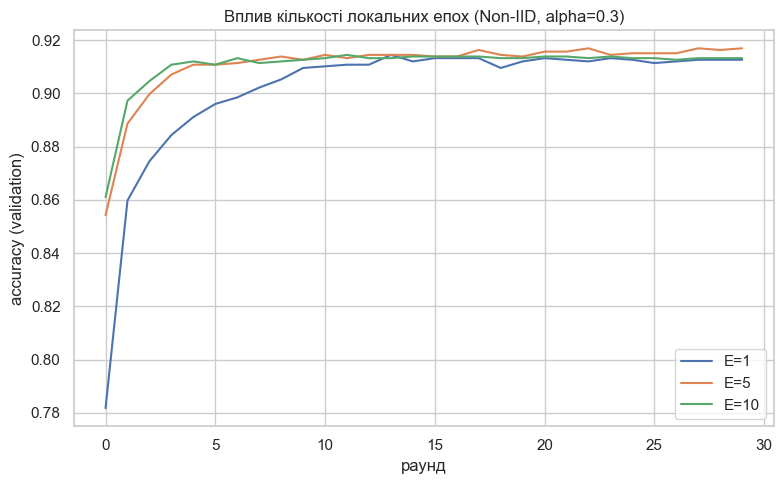

In [39]:
plt.figure(figsize=(8, 5))
for E in Es:
    plt.plot(E_hist[E]["val_acc"], label=f"E={E}")
plt.xlabel("раунд"); plt.ylabel("accuracy (validation)")
plt.title("Вплив кількості локальних епох (Non-IID, alpha=0.3)")
plt.legend(); plt.tight_layout(); plt.show()

**Висновок.** Більше локальних епох (E) означає, що за один раунд зв'язку
клієнт встигає зробити більше кроків навчання — тому на перших раундах криві
з E=5 чи E=10 зазвичай ростуть швидше за E=1. Це головна практична вигода:
менше раундів зв'язку потрібно для тієї самої якості.

Але в Non-IID сценарії за велике E доводиться платити — це називається
**client drift (клієнтський дрейф)**: якщо дати клієнту забагато локальних
епох, він встигає майже повністю "з'їхати" у свій власний локальний оптимум,
який далеко від того, що потрібно всім разом. Коли потім такі далеко "розбіглі"
моделі усереднюють, результат може вийти гіршим, ніж якби синхронізувались
частіше — крива стає нерівною і виходить на нижче плато.

Тобто E — це компроміс: більше E економить комунікацію, але при сильній
неоднорідності краще брати E поменше, щоб клієнти не встигали "втекти" надто
далеко один від одного.

## Етап 7 (додатково). Експеримент А: вплив кількості клієнтів K

          model  accuracy  macro_F1  balanced_acc  log_loss  min_n_k
K                                                                   
3    FedAvg K=3    0.9154    0.9275        0.9274    0.2344     2118
5    FedAvg K=5    0.9129    0.9246        0.9237    0.2431     1326
10  FedAvg K=10    0.9149    0.9272        0.9266    0.2417      247


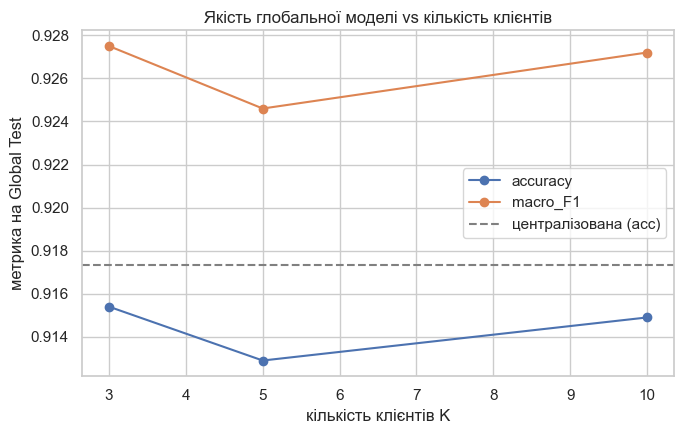

In [40]:
K_rows = []
for Kx in [3, 5, 10]:
    idx_k = split_dirichlet(y_pool, Kx, alpha=1.0)
    m_k, h_k = fedavg(idx_k, Xp_s, y_pool, Xv_s, y_val, rounds=ROUNDS,
                      local_epochs=E_DEFAULT, lr=BEST_LR, lam=BEST_LAM, batch_size=BEST_BS)
    r = evaluate(m_k, Xt_s, y_test, f"FedAvg K={Kx}")
    r["K"] = Kx
    r["min_n_k"] = min(len(i) for i in idx_k)
    K_rows.append(r)

K_df = pd.DataFrame(K_rows).set_index("K").round(4)
print(K_df)

K_df[["accuracy", "macro_F1"]].plot(marker="o", figsize=(7, 4.5))
plt.axhline(base_metrics["accuracy"], ls="--", c="gray", label="централізована (acc)")
plt.xlabel("кількість клієнтів K"); plt.ylabel("метрика на Global Test")
plt.title("Якість глобальної моделі vs кількість клієнтів")
plt.legend(); plt.tight_layout(); plt.show()

**Висновок.** Загальна кількість даних не змінюється, змінюється лише те, на
скільки частин її розрізали. Що більше K, то менше прикладів дістається
кожному окремому клієнту, а значить його локальне навчання стає "шумнішим" і
менш надійним. Через це якість глобальної моделі трохи падає зі збільшенням K
(або потрібно більше раундів, щоб досягти тієї самої якості). При не дуже
сильній неоднорідності це падіння невелике — усереднення відразу багатьох
клієнтів частково "згладжує" шум від того, що в кожного окремо даних мало.

## Теоретичні питання

**1. Чому для багатокласової класифікації використовують softmax?**
Тому що softmax перетворює будь-які "сирі" числа (логіти) на нормальні
ймовірності: усі значення виходять додатні і в сумі дають 1. Ще softmax
влаштований так, що якщо ймовірність одного класу росте, то ймовірності інших
автоматично трохи падають — а це саме те, що нам треба, бо кожен об'єкт
належить рівно до одного класу з семи.

**2. Чому крос-ентропія — природна функція втрат для логістичної регресії?**
Тому що вона напряму штрафує модель за впевненість у неправильній відповіді:
якщо модель дала правильному класу маленьку ймовірність, $-\log p$ буде дуже
великим числом (і навпаки — якщо ймовірність близька до 1, штраф майже
нульовий). Це саме та поведінка, яку хочемо від функції втрат. Якби замість
цього ми взяли, наприклад, звичайну MSE (як у регресії), то градієнти при
сильних помилках виходили б надто маленькими, і модель вчилась би дуже повільно.

**3. Чим Ridge відрізняється від Lasso?**
Обидва — це способи "штрафувати" модель за занадто великі ваги, щоб вона не
підлаштовувалась під шум. Ridge (L2) додає до втрат суму квадратів ваг: він
рівномірно зменшує всі ваги, наближаючи їх до нуля, але майже ніколи не робить
рівно нулем. Lasso (L1) додає суму модулів ваг: через це частина ваг стає
**точно нулем** — тобто Lasso сам "викидає" непотрібні ознаки. Якщо коротко:
Ridge просто робить модель спокійнішою, а Lasso ще й відбирає ознаки за нас.

**4. Чому параметр зміщення b зазвичай не регуляризують?**
Бо b відповідає не за якусь конкретну ознаку, а за загальний рівень — умовно,
"наскільки часто взагалі зустрічається цей клас". Якщо його теж штрафувати,
модель почне занижувати відповіді для частих класів без жодної на те причини,
пов'язаної з даними. Тобто штраф на b просто не має сенсу — регуляризація
потрібна саме для ваг при ознаках.

**5. Що таке Data Leakage?**
Це коли модель під час навчання випадково "підглядає" інформацію, якої в
реальному житті в неї не буде. Найпростіший приклад — порахувати параметри
масштабування або відібрати ознаки на всьому датасеті одразу, включно з
тестом. Тоді результат на тесті буде виглядати кращим, ніж модель покаже
насправді на нових даних.

**6. Чому тестову вибірку не можна використовувати для підбору гіперпараметрів?**
Бо якщо перебирати багато варіантів гіперпараметрів і щоразу дивитись на тест,
рано чи пізно ми оберемо той варіант, який просто випадково "вдало ліг" саме
на цей тест — а не той, що дійсно найкращий. Тест перестане бути чесною
перевіркою на нових даних. Тому для підбору є окрема Global Validation, а тест
чіпаємо один-єдиний раз, у самому кінці.

**7. Чому параметри масштабування треба рахувати лише на тренувальних даних?**
Тому що середнє й дисперсія — це теж інформація, "вивчена" з даних, а не
щось універсальне. Якщо порахувати їх з урахуванням тесту, тест уже не буде
чесно імітувати "нові, ще не бачені дані" — а саме так модель і
використовуватиметься в реальному житті.

**8. Що таке федеративне навчання і в чому його плюси?**
Це спосіб навчати одну спільну модель на даних, які лежать у різних людей чи
організацій і фізично нікуди не переміщуються. Замість даних між клієнтами і
сервером ходять тільки параметри моделі (ваги). Головні плюси: дані
залишаються приватними; не треба возити великі об'єми сирих даних; можна
навчитись на даних, які взагалі неможливо зібрати в одному місці; і кожен
учасник у підсумку отримує модель кращу, ніж міг би навчити сам.

**9. Чому сервер не повинен отримувати сирі дані клієнтів?**
Тому що в цьому і є весь сенс федеративного навчання — якщо сервер все одно
отримає сирі дані, простіше було б одразу зібрати їх в одному місці і навчити
звичайну централізовану модель. До того ж такі дані часто приватні
(персональні, медичні, комерційні), і власники просто не погодяться їх
віддавати.

**10. Чому FedAvg зважує оновлення клієнтів за кількістю їхніх прикладів?**
Бо клієнт із великою вибіркою дає більш надійну оцінку того, "куди рухати
модель", ніж клієнт з маленькою і, можливо, випадковою вибіркою. Це так само,
як у звичайному навчанні на об'єднаних даних: кожен приклад важить однаково,
а не кожен клієнт.

**11. Що станеться, якщо агрегувати без зважування (просто середнє)?**
Тоді клієнт із 50 прикладами матиме такий самий вплив на глобальну модель,
як клієнт із 5000. Маленький клієнт частіше дає "шумний" і нерепрезентативний
результат, і якщо його рахувати нарівні з великим, глобальна модель почне
"смикатись" у бік цього шуму — якість, особливо macro-F1, впаде.

**12. Що таке Non-IID дані?**
Це коли в різних клієнтів дані по суті "різні": в одного одні класи
трапляються частіше, в іншого — інші, десь узагалі відсутній якийсь клас,
десь просто дуже мало прикладів. Тобто немає такого, що кожен клієнт має
"випадковий шматочок" від однієї й тієї самої загальної картини — картини
насправді трохи різні.

**13. Чому федеративне навчання гірше працює на Non-IID даних?**
Тому що кожен клієнт по суті вчить трохи свою версію задачі і рухається у
свій локальний оптимум. Коли ми потім усереднюємо кілька моделей, які
"розбіглись" у різні боки, результат — це компроміс, який не є насправді
хорошим розв'язком для жодного з клієнтів окремо, і часто гірший за те, що
дала б централізована модель.

**14. Що таке клієнтський дрейф (client drift)?**
Це коли за час локального навчання (за багато епох E) модель клієнта встигає
"втекти" далеко в бік свого власного локального оптимуму — тобто дуже
підлаштуватись саме під свої дані. Що сильніше дані клієнтів відрізняються
одне від одного і що більше E, то далі "розбігаються" локальні моделі одна
від одної, і тим гірше виходить після усереднення.

**15. Як кількість локальних епох E впливає на глобальну модель?**
Мале E означає, що клієнти встигають зробити лише невеликий крок перед тим,
як надіслати ваги назад — це стабільніше, але потребує більше раундів
зв'язку. Велике E економить раунди зв'язку, але за неоднорідних даних сильно
підвищує ризик client drift — модель клієнта "втікає" надто далеко, і після
усереднення якість падає. При IID даних велике E майже не шкодить.

**16. Чи може глобальна модель бути гіршою за централізовану? Чому?**
Так, і зазвичай саме так і є. Централізована модель одразу вчиться на всіх
даних разом, а FedAvg лише усереднює кілька моделей, навчених окремо — це
завжди лише наближення до того, що дала б централізована модель, а не те
саме. Різниця росте разом з неоднорідністю даних (Non-IID) і з великим E; при
IID і невеликому E вона майже непомітна.

**17. Які метрики краще використовувати при дисбалансі класів?**
Macro-F1 і balanced accuracy — бо вони дають кожному класу однакову вагу,
незалежно від того, скільки в ньому прикладів. Корисно також дивитись на
confusion matrix, щоб побачити, які саме класи плутаються між собою, і на
log-loss, який враховує ще й впевненість моделі. Звичайну accuracy саму по
собі краще не використовувати як головну метрику — вона легко "обманює",
коли класів багато, і не всі однакові за розміром.

##  Загальний висновок

1. Pеалізувала багатокласову логістичну регресію: softmax
   (з відніманням максимуму для стабільності), крос-ентропію з
   Ridge-регуляризацією, градієнти (перевірила їх числовим методом — збіглись),
   і навчання міні-батчевим градієнтним спуском без жодного циклу по окремих
   прикладах.
2. Дані розбила правильно: спочатку відрізали Global Test і Global Validation,
   і тільки потім (на тому, що лишилось) робили відбір ознак і масштабування.
   Тест використали рівно один раз — у самому кінці.
3. Централізована модель — це наша "стеля", з якою порівнюємо все інше.
4. Головний результат роботи: FedAvg зі зваженою агрегацією дає якість, дуже
   близьку до централізованої моделі, хоча сервер жодного разу не бачив сирих
   даних жодного клієнта.
5. Неоднорідність даних (Non-IID) — головний ворог федеративного навчання, бо
   чим менша alpha, тим гірша фінальна якість і тим нерівніше йде навчання.
6. Кількість локальних епох E — це компроміс: більше E економить раунди
   зв'язку, але при сильній неоднорідності підвищує client drift і шкодить
   якості.
7. Локальна модель окремого клієнта завжди гірша за глобальну на спільному
   тесті — це і є головний аргумент, навіщо взагалі брати участь у
   федеративному навчанні.
8. Через дисбаланс класів судити про якість моделі треба за macro-F1 і
   balanced accuracy, а не тільки за accuracy — вона легко вводить в оману.